# ICU Length of Stay — Pipeline ML (MIMIC-III)

**Objetivo:** Análise estatística de eventos clínicos de doentes em UCI e previsão do tempo de internamento (*length of stay*) usando um pipeline de Machine Learning distribuído com PySpark.

**Dataset:** MIMIC-III — `CHARTEVENTS.csv.gz` (~4.2 GB comprimido, ~330M linhas)

**Pipeline:**
1. Setup do ambiente (Java 21 + PySpark 4.1.2)
2. Ingestão e conversão para Parquet
3. Análise estatística e visualização por paciente
4. Pré-processamento e feature engineering
5. Preparação dos dados para ML
6. Treino e validação de modelos
7. Análise de resultados
8. Performance e profiling

---
## Capítulo 0 — Setup do Ambiente

Configuração do Java 21, PySpark 4.1.2 e sessão Spark com parâmetros ajustados à RAM disponível


In [1]:
import os
import subprocess
import psutil

# --- Java 21 (obrigatório para PySpark 4.x) ---
JAVA_HOME = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot"
os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["PATH"] = JAVA_HOME + r"\bin;" + os.environ["PATH"]

java_ver = subprocess.run(["java", "-version"], capture_output=True, text=True).stderr
print(java_ver)
assert "21" in java_ver, "Java 21 nao encontrado — verifica o caminho JAVA_HOME"

HADOOP_HOME = r"C:\hadoop"
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["PATH"] = HADOOP_HOME + r"\bin;" + os.environ["PATH"]
print(f"HADOOP_HOME: {HADOOP_HOME}")


openjdk version "21.0.11" 2026-04-21 LTS
OpenJDK Runtime Environment Temurin-21.0.11+10 (build 21.0.11+10-LTS)
OpenJDK 64-Bit Server VM Temurin-21.0.11+10 (build 21.0.11+10-LTS, mixed mode, sharing)

HADOOP_HOME: C:\hadoop


In [2]:
import urllib.request
from pathlib import Path

# --- Descarregar winutils.exe e hadoop.dll
hadoop_bin = Path(r"C:\hadoop\bin")
hadoop_bin.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.6/bin"
files = ["winutils.exe", "hadoop.dll"]

for fname in files:
    dest = hadoop_bin / fname
    if not dest.exists():
        print(f"A descarregar {fname}...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", dest)
        print(f"  -> guardado em {dest}")
    else:
        print(f"  {fname} já existe — OK")

print("\n Spark pronto a ser criado.")


  winutils.exe já existe — OK
  hadoop.dll já existe — OK

 Spark pronto a ser criado.


In [3]:
# --- Diagnóstico de memória ---
ram = psutil.virtual_memory()
print(f"RAM total:      {ram.total / 1e9:.1f} GB")
print(f"RAM disponível: {ram.available / 1e9:.1f} GB")
print(f"RAM usada:      {ram.percent}%")

RAM total:      34.1 GB
RAM disponível: 20.8 GB
RAM usada:      39.1%


In [4]:
from pyspark.sql import SparkSession

# Encerrar sessão anterior se existir
existing = SparkSession.getActiveSession()
if existing:
    existing.stop()

# --- Criar sessão Spark optimizada para 34 GB RAM ---
spark = SparkSession.builder \
    .appName("ICU_LOS") \
    .master("local[*]") \
    .config("spark.driver.memory",          "16g") \
    .config("spark.executor.memory",        "4g")  \
    .config("spark.driver.maxResultSize",   "4g")  \
    .config("spark.sql.shuffle.partitions", "16")  \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

Spark version: 4.1.2
Spark UI: http://localhost:4040


---
## Capítulo 1 — Ingestão dos Dados

Leitura do `CHARTEVENTS.csv.gz` com schema explícito (evita `inferSchema` que percorre o ficheiro inteiro).
Na primeira execução converte para **Parquet** particionado por `SUBJECT_ID` — 10-20x mais rápido em todas as operações seguintes.

| Ficheiro | Tamanho | Descrição |
|---|---|---|
| `CHARTEVENTS.csv.gz` | ~4.2 GB | Eventos clínicos de doentes em UCI |
| `D_ITEMS.csv.gz` | ~1 MB | Dicionário de items (ITEMID → descrição) |
| `ADMISSIONS.csv.gz` | ~10 MB | Admissões hospitalares (datas entrada/saída) |


In [5]:
from pathlib import Path
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType

data_dir   = Path.cwd()
chart_path = data_dir / "CHARTEVENTS.csv.gz"
items_path = data_dir / "D_ITEMS.csv.gz"
adm_path   = data_dir / "ADMISSIONS.csv.gz"
parquet_path = data_dir / "CHARTEVENTS.parquet"

if not chart_path.exists():
    raise FileNotFoundError(f"Ficheiro nao encontrado: {chart_path}")

def spark_path(path: Path) -> str:
    """Converte Path para URI compatível com Spark no Windows."""
    return path.resolve().as_uri()

In [6]:
# --- Schema explícito: evita inferSchema (poupa ~2 min) ---
chart_schema = StructType([
    StructField("ROW_ID",       IntegerType(), True),
    StructField("SUBJECT_ID",   IntegerType(), True),
    StructField("HADM_ID",      IntegerType(), True),
    StructField("ICUSTAY_ID",   IntegerType(), True),
    StructField("ITEMID",       IntegerType(), True),
    StructField("CHARTTIME",    StringType(),  True),
    StructField("STORETIME",    StringType(),  True),
    StructField("CGID",         IntegerType(), True),
    StructField("VALUE",        StringType(),  True),
    StructField("VALUENUM",     DoubleType(),  True),
    StructField("VALUEUOM",     StringType(),  True),
    StructField("WARNING",      IntegerType(), True),
    StructField("ERROR",        IntegerType(), True),
    StructField("RESULTSTATUS", StringType(),  True),
    StructField("STOPPED",      StringType(),  True),
])

try:
    df_chart = spark.read \
        .option("header", True) \
        .schema(chart_schema) \
        .csv(spark_path(chart_path))
    print(f"CHARTEVENTS colunas: {len(df_chart.columns)}")
    print(df_chart.columns)
except Exception as e:
    print(f"ERRO: {type(e).__name__}: {e}")

df_items = spark.read.option("header", True).csv(spark_path(items_path)) if items_path.exists() else None
df_adm   = spark.read.option("header", True).csv(spark_path(adm_path))   if adm_path.exists() else None

if df_items is None: print(f"Aviso: ficheiro ausente -> {items_path.name}")
if df_adm   is None: print(f"Aviso: ficheiro ausente -> {adm_path.name}")

CHARTEVENTS colunas: 15
['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'ITEMID', 'CHARTTIME', 'STORETIME', 'CGID', 'VALUE', 'VALUENUM', 'VALUEUOM', 'WARNING', 'ERROR', 'RESULTSTATUS', 'STOPPED']
Aviso: ficheiro ausente -> D_ITEMS.csv.gz
Aviso: ficheiro ausente -> ADMISSIONS.csv.gz


In [7]:
# ============================================================
# 1.3 — CONVERSÃO / RECARREGAMENTO DO CHARTEVENTS PARA PARQUET
# ============================================================

import time
import shutil

# If Parquet folder exists but is empty/corrupted, delete it
if parquet_path.exists():
    parquet_files = list(parquet_path.rglob("*.parquet"))
    
    if len(parquet_files) == 0:
        print("Parquet existe mas não contém ficheiros .parquet.")
        print("A remover pasta Parquet corrompida/incompleta...")
        shutil.rmtree(parquet_path)
    else:
        print(f"Parquet existente válido: {len(parquet_files)} ficheiros encontrados.")

# Convert only if Parquet does not exist
if not parquet_path.exists():
    print("A converter CHARTEVENTS.csv.gz para Parquet...")
    print("Acompanha o progresso em http://localhost:4040\n")
    
    t0 = time.time()

    (
        df_chart
        .write
        .mode("overwrite")
        .partitionBy("SUBJECT_ID")
        .parquet(spark_path(parquet_path))
    )

    elapsed = time.time() - t0

    print(f"Conversão concluída em {elapsed / 60:.1f} min")
    print(f"Parquet guardado em: {parquet_path}")

else:
    print(f"Parquet já existe — a carregar de: {parquet_path}")

# Reload from Parquet
df_chart = spark.read.parquet(spark_path(parquet_path))

print(f"\nColunas: {df_chart.columns}")
print("CHARTEVENTS Parquet carregado com sucesso.")

Parquet existente válido: 46467 ficheiros encontrados.
Parquet já existe — a carregar de: c:\Users\Admin\Desktop\MIMIC-EDU\CHARTEVENTS.parquet

Colunas: ['ROW_ID', 'HADM_ID', 'ICUSTAY_ID', 'ITEMID', 'CHARTTIME', 'STORETIME', 'CGID', 'VALUE', 'VALUENUM', 'VALUEUOM', 'WARNING', 'ERROR', 'RESULTSTATUS', 'STOPPED', 'SUBJECT_ID']
CHARTEVENTS Parquet carregado com sucesso.


In [7]:
# ============================================================
# RELOAD EXISTING PARQUET
# ============================================================

from pathlib import Path

parquet_path = Path(r".\CHARTEVENTS.parquet")

df_chart = spark.read.parquet(parquet_path.resolve().as_uri())

print("Parquet loaded successfully.")

print("\nColumns:")
print(df_chart.columns)

print("\nSchema:")
df_chart.printSchema()

Parquet loaded successfully.

Columns:
['ROW_ID', 'HADM_ID', 'ICUSTAY_ID', 'ITEMID', 'CHARTTIME', 'STORETIME', 'CGID', 'VALUE', 'VALUENUM', 'VALUEUOM', 'WARNING', 'ERROR', 'RESULTSTATUS', 'STOPPED', 'SUBJECT_ID']

Schema:
root
 |-- ROW_ID: integer (nullable = true)
 |-- HADM_ID: integer (nullable = true)
 |-- ICUSTAY_ID: integer (nullable = true)
 |-- ITEMID: integer (nullable = true)
 |-- CHARTTIME: string (nullable = true)
 |-- STORETIME: string (nullable = true)
 |-- CGID: integer (nullable = true)
 |-- VALUE: string (nullable = true)
 |-- VALUENUM: double (nullable = true)
 |-- VALUEUOM: string (nullable = true)
 |-- WARNING: integer (nullable = true)
 |-- ERROR: integer (nullable = true)
 |-- RESULTSTATUS: string (nullable = true)
 |-- STOPPED: string (nullable = true)
 |-- SUBJECT_ID: integer (nullable = true)



---
## Capítulo 2 — Análise Estatística e Visualização

Análise exploratória por `SUBJECT_ID` e `ICUSTAY_ID`:
- Estatísticas descritivas por estadia (contagem, média, desvio padrão, min, max)
- Identificação de outliers nos valores clínicos
- Visualização temporal de eventos por paciente


### 2.1 Estatísticas descritivas por SUBJECT_ID / ICUSTAY_ID

In [8]:
from pyspark.sql.functions import col, count, mean, stddev, min, max

stats = df_chart.groupBy("SUBJECT_ID", "ICUSTAY_ID") \
    .agg(
        count("*")         .alias("n_events"),
        mean("VALUENUM")   .alias("mean_val"),
        stddev("VALUENUM") .alias("std_val"),
        min("VALUENUM")    .alias("min_val"),
        max("VALUENUM")    .alias("max_val"),
    )

try:
    stats.show(5, truncate=False)
except Exception as e:
    print(f"ERRO: {type(e).__name__}: {e}")

+----------+----------+--------+-----------------+------------------+-------------------+-------+
|SUBJECT_ID|ICUSTAY_ID|n_events|mean_val         |std_val           |min_val            |max_val|
+----------+----------+--------+-----------------+------------------+-------------------+-------+
|11923     |275574    |9441    |83.30789288587081|277.75615496457925|-45.0              |7287.0 |
|6365      |234114    |12082   |55.55573996303061|67.2032641132314  |-0.4000000059604645|637.0  |
|27427     |246501    |11961   |86.03696792114553|199.81132649532066|-4.0               |3000.0 |
|27427     |203143    |72753   |58.29286704384683|197.16744889848292|-250.0             |4717.0 |
|27427     |207593    |3246    |35.07726799653081|87.7039924613364  |0.0                |2500.0 |
+----------+----------+--------+-----------------+------------------+-------------------+-------+
only showing top 5 rows


### 2.2 Identificação de outliers

Valores com `std_val` muito elevado ou `max_val` extremo indicam outliers que precisam de tratamento no pré-processamento.
Exemplo observado: `SUBJECT_ID=671` com `max_val=219219` e `std_val=4028`.

In [9]:
from pyspark.sql.functions import desc, percentile_approx, expr

# Top 10 estadias com maior variabilidade — candidatos a outliers
stats.orderBy(desc("std_val")).show(10, truncate=False)

+----------+----------+--------+------------------+------------------+-------+---------+
|SUBJECT_ID|ICUSTAY_ID|n_events|mean_val          |std_val           |min_val|max_val  |
+----------+----------+--------+------------------+------------------+-------+---------+
|32005     |202559    |1216    |14724.338162544173|349251.88667708816|0.0    |8309010.0|
|92373     |256824    |4201    |5625.00158862876  |236094.88097281184|-7.0   |9999999.0|
|49615     |298310    |3932    |4941.945817025436 |221185.87541353135|-3.0   |9999999.0|
|60552     |221208    |4506    |5383.225067961165 |209630.0882386926 |-10.0  |8239872.0|
|66405     |287031    |9949    |2568.9220335551086|147200.61722118082|-4.0   |8654765.1|
|71011     |228194    |3095    |3027.78019520852  |99290.64099438276 |-4.0   |3333331.0|
|48882     |224325    |15726   |1125.9171559750023|94964.32316747136 |-14.0  |8409010.0|
|84020     |210970    |2414    |2664.6301306620203|88519.50170561095 |-3.0   |2999280.0|
|40124     |279554   

#### 2.2.1 Cálculo de outliers por IQR para os ITEMIDs mais frequentes

In [10]:
import pandas as pd
import numpy as np

# Seleccionar top ITEMIDs para análise de outliers
TOP_N_ITEMS = 8

top_items_counts = df_chart.groupBy("ITEMID") \
    .count() \
    .orderBy(desc("count")) \
    .limit(TOP_N_ITEMS) \
    .toPandas()

top_item_ids = top_items_counts["ITEMID"].tolist()
print(f"Top {TOP_N_ITEMS} ITEMIDs: {top_item_ids}")

# Recolher amostra para análise em pandas
df_sample = df_chart.filter(col("ITEMID").isin(top_item_ids)) \
    .select("ITEMID", "VALUENUM") \
    .dropna(subset=["VALUENUM"]) \
    .toPandas()

# Calcular limites IQR por ITEMID
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

bounds = {}
for item in top_item_ids:
    vals = df_sample[df_sample["ITEMID"] == item]["VALUENUM"]
    lo, hi = iqr_bounds(vals)
    n_out = ((vals < lo) | (vals > hi)).sum()
    bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
    print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")

Top 8 ITEMIDs: [211, 742, 646, 618, 212, 161, 128, 550]
ITEM     211: [-16.0, 240.0]  outliers=64 (0.0%)
ITEM     742: [1.0, 1.0]  outliers=0 (0.0%)
ITEM     646: [90.0, 106.0]  outliers=59521 (1.7%)
ITEM     618: [4.0, 36.0]  outliers=64765 (1.9%)
ITEM     212: [nan, nan]  outliers=0 (nan%)
ITEM     161: [nan, nan]  outliers=0 (nan%)
ITEM     128: [nan, nan]  outliers=0 (nan%)
ITEM     550: [nan, nan]  outliers=0 (nan%)


C:\Users\elman\AppData\Local\Temp\ipykernel_13652\2044035399.py:33: RuntimeWarning: invalid value encountered in scalar divide
  bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
C:\Users\elman\AppData\Local\Temp\ipykernel_13652\2044035399.py:34: RuntimeWarning: invalid value encountered in scalar divide
  print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")
C:\Users\elman\AppData\Local\Temp\ipykernel_13652\2044035399.py:33: RuntimeWarning: invalid value encountered in scalar divide
  bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
C:\Users\elman\AppData\Local\Temp\ipykernel_13652\2044035399.py:34: RuntimeWarning: invalid value encountered in scalar divide
  print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")
C:\Users\elman\AppData\Local\Temp\ipykernel_13652\2044035399.py:33: RuntimeWarning: invalid value encountered in scala

#### 2.2.2 Boxplot — Distribuição e outliers por ITEMID

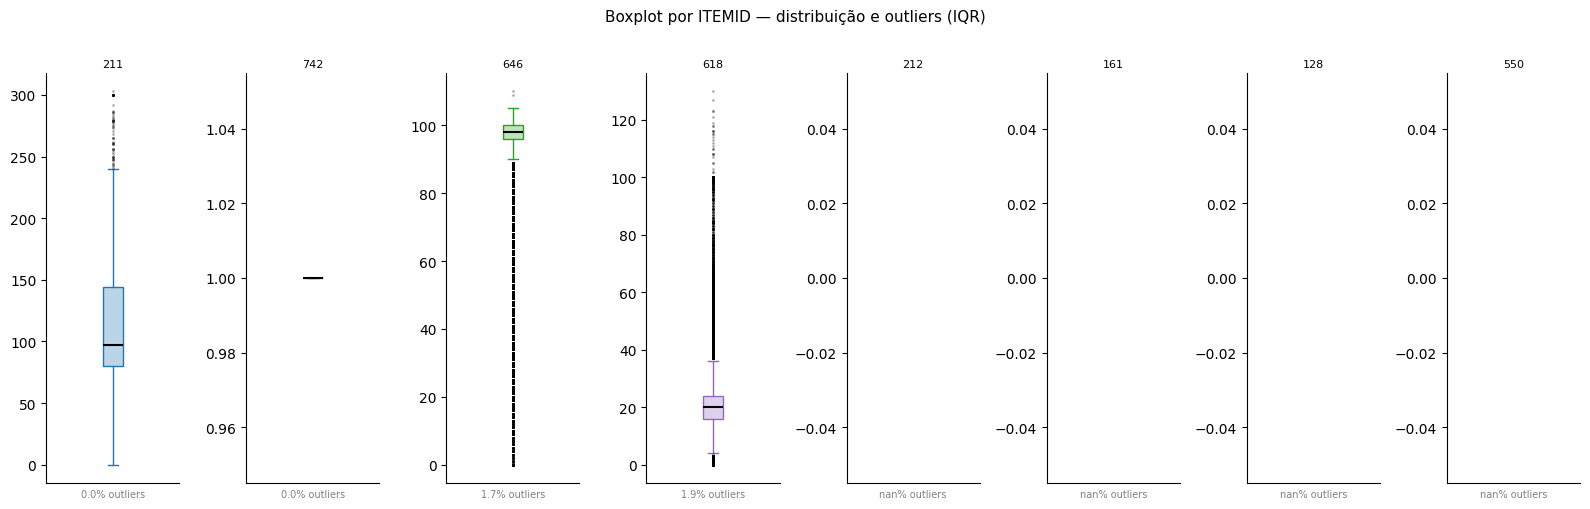

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ITEM_LABELS = {
    220045: "FC (bpm)",
    220050: "PAS invasiva (mmHg)",
    220051: "PAD invasiva (mmHg)",
    220052: "PAM invasiva (mmHg)",
    220179: "PAS não-invasiva (mmHg)",
    220180: "PAD não-invasiva (mmHg)",
    220210: "FR (rpm)",
    220277: "SpO2 (%)",
    220739: "GCS — olhos",
    223753: "GCS — motor",
    223762: "Temperatura (°C)",
}

fig, axes = plt.subplots(1, len(top_item_ids), figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_item_ids)))

for ax, item, color in zip(axes, top_item_ids, colors):
    vals = df_sample[df_sample["ITEMID"] == item]["VALUENUM"].dropna()
    bp = ax.boxplot(vals, patch_artist=True, notch=False,
                    flierprops=dict(marker=".", markersize=2, alpha=0.3, color=color),
                    medianprops=dict(color="black", linewidth=1.5),
                    boxprops=dict(facecolor=(*color[:3], 0.3), edgecolor=color),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color))
    label = ITEM_LABELS.get(item, str(item))
    ax.set_title(label, fontsize=8, pad=4)
    ax.set_xticks([])
    ax.spines[["top", "right"]].set_visible(False)
    pct = bounds[item]["pct"]
    ax.set_xlabel(f"{pct:.1f}% outliers", fontsize=7, color="gray")

fig.suptitle("Boxplot por ITEMID — distribuição e outliers (IQR)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("viz_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2.2.3 Scatter antes vs. depois da remoção de outliers

C:\Users\elman\AppData\Local\Temp\ipykernel_13652\906440764.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\elman\AppData\Local\Temp\ipykernel_13652\906440764.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("viz_outliers_before_after.png", dpi=150, bbox_inches="tight")
C:\Users\elman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


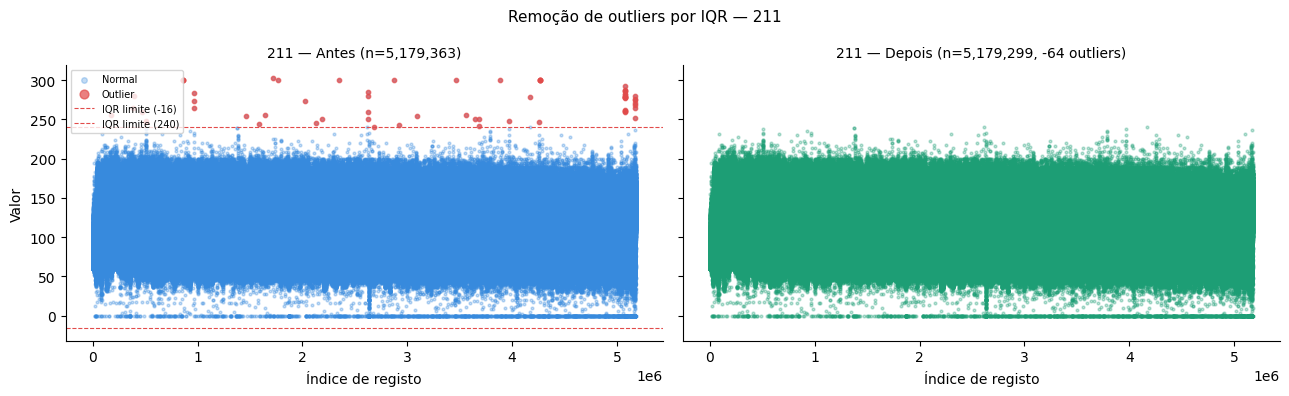

In [14]:
# Seleccionar um ITEMID representativo para comparação visual
ITEM_COMPARE = top_item_ids[0]  # ex: FC (bpm)
label_compare = ITEM_LABELS.get(ITEM_COMPARE, str(ITEM_COMPARE))

vals_all = df_sample[df_sample["ITEMID"] == ITEM_COMPARE]["VALUENUM"].reset_index(drop=True)
lo, hi = bounds[ITEM_COMPARE]["lo"], bounds[ITEM_COMPARE]["hi"]
mask_ok = (vals_all >= lo) & (vals_all <= hi)
vals_clean = vals_all[mask_ok]
vals_out   = vals_all[~mask_ok]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# --- Antes ---
axes[0].scatter(range(len(vals_all)), vals_all, s=4, alpha=0.3, color="#378ADD", label="Normal")
axes[0].scatter(vals_out.index, vals_out, s=10, alpha=0.7, color="#E24B4A", label="Outlier", zorder=3)
axes[0].axhline(lo, color="#E24B4A", linestyle="--", linewidth=0.8, label=f"IQR limite ({lo:.0f})")
axes[0].axhline(hi, color="#E24B4A", linestyle="--", linewidth=0.8, label=f"IQR limite ({hi:.0f})")
axes[0].set_title(f"{label_compare} — Antes (n={len(vals_all):,})", fontsize=10)
axes[0].set_xlabel("Índice de registo")
axes[0].set_ylabel("Valor")
axes[0].legend(fontsize=7, markerscale=2)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Depois ---
axes[1].scatter(range(len(vals_clean)), vals_clean, s=4, alpha=0.3, color="#1D9E75")
axes[1].set_title(f"{label_compare} — Depois (n={len(vals_clean):,}, -{len(vals_out):,} outliers)", fontsize=10)
axes[1].set_xlabel("Índice de registo")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Remoção de outliers por IQR — {label_compare}", fontsize=11)
plt.tight_layout()
plt.savefig("viz_outliers_before_after.png", dpi=150, bbox_inches="tight")
plt.show()


#### 2.2.4 Histograma — Distribuição antes e depois da remoção de outliers

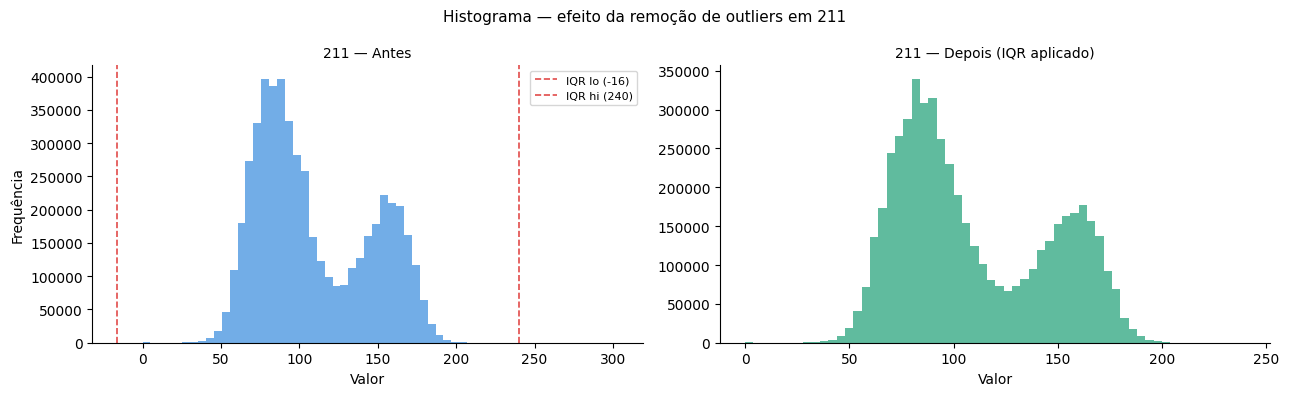

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins_hist = 60

axes[0].hist(vals_all, bins=bins_hist, color="#378ADD", alpha=0.7, edgecolor="none")
axes[0].axvline(lo, color="#E24B4A", linestyle="--", linewidth=1.2, label=f"IQR lo ({lo:.0f})")
axes[0].axvline(hi, color="#E24B4A", linestyle="--", linewidth=1.2, label=f"IQR hi ({hi:.0f})")
axes[0].set_title(f"{label_compare} — Antes", fontsize=10)
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frequência")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(vals_clean, bins=bins_hist, color="#1D9E75", alpha=0.7, edgecolor="none")
axes[1].set_title(f"{label_compare} — Depois (IQR aplicado)", fontsize=10)
axes[1].set_xlabel("Valor")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Histograma — efeito da remoção de outliers em {label_compare}", fontsize=11)
plt.tight_layout()
plt.savefig("viz_histogram_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Visualização temporal por ICUSTAY_ID

Scatter plot dos sinais vitais de uma estadia UCI (`ICUSTAY_ID = 200072`), com o tempo
normalizado no eixo X (0 = admissão, 1 = alta) e o valor de cada métrica no eixo Y.

Os registos são agrupados em bins de 0.2 e agregados pela média, reduzindo o ruído dos
registos individuais. Cada subplot corresponde a um dos 8 ITEMIDs mais frequentes,
com o nome clínico mapeado via dicionário `ITEM_LABELS`.

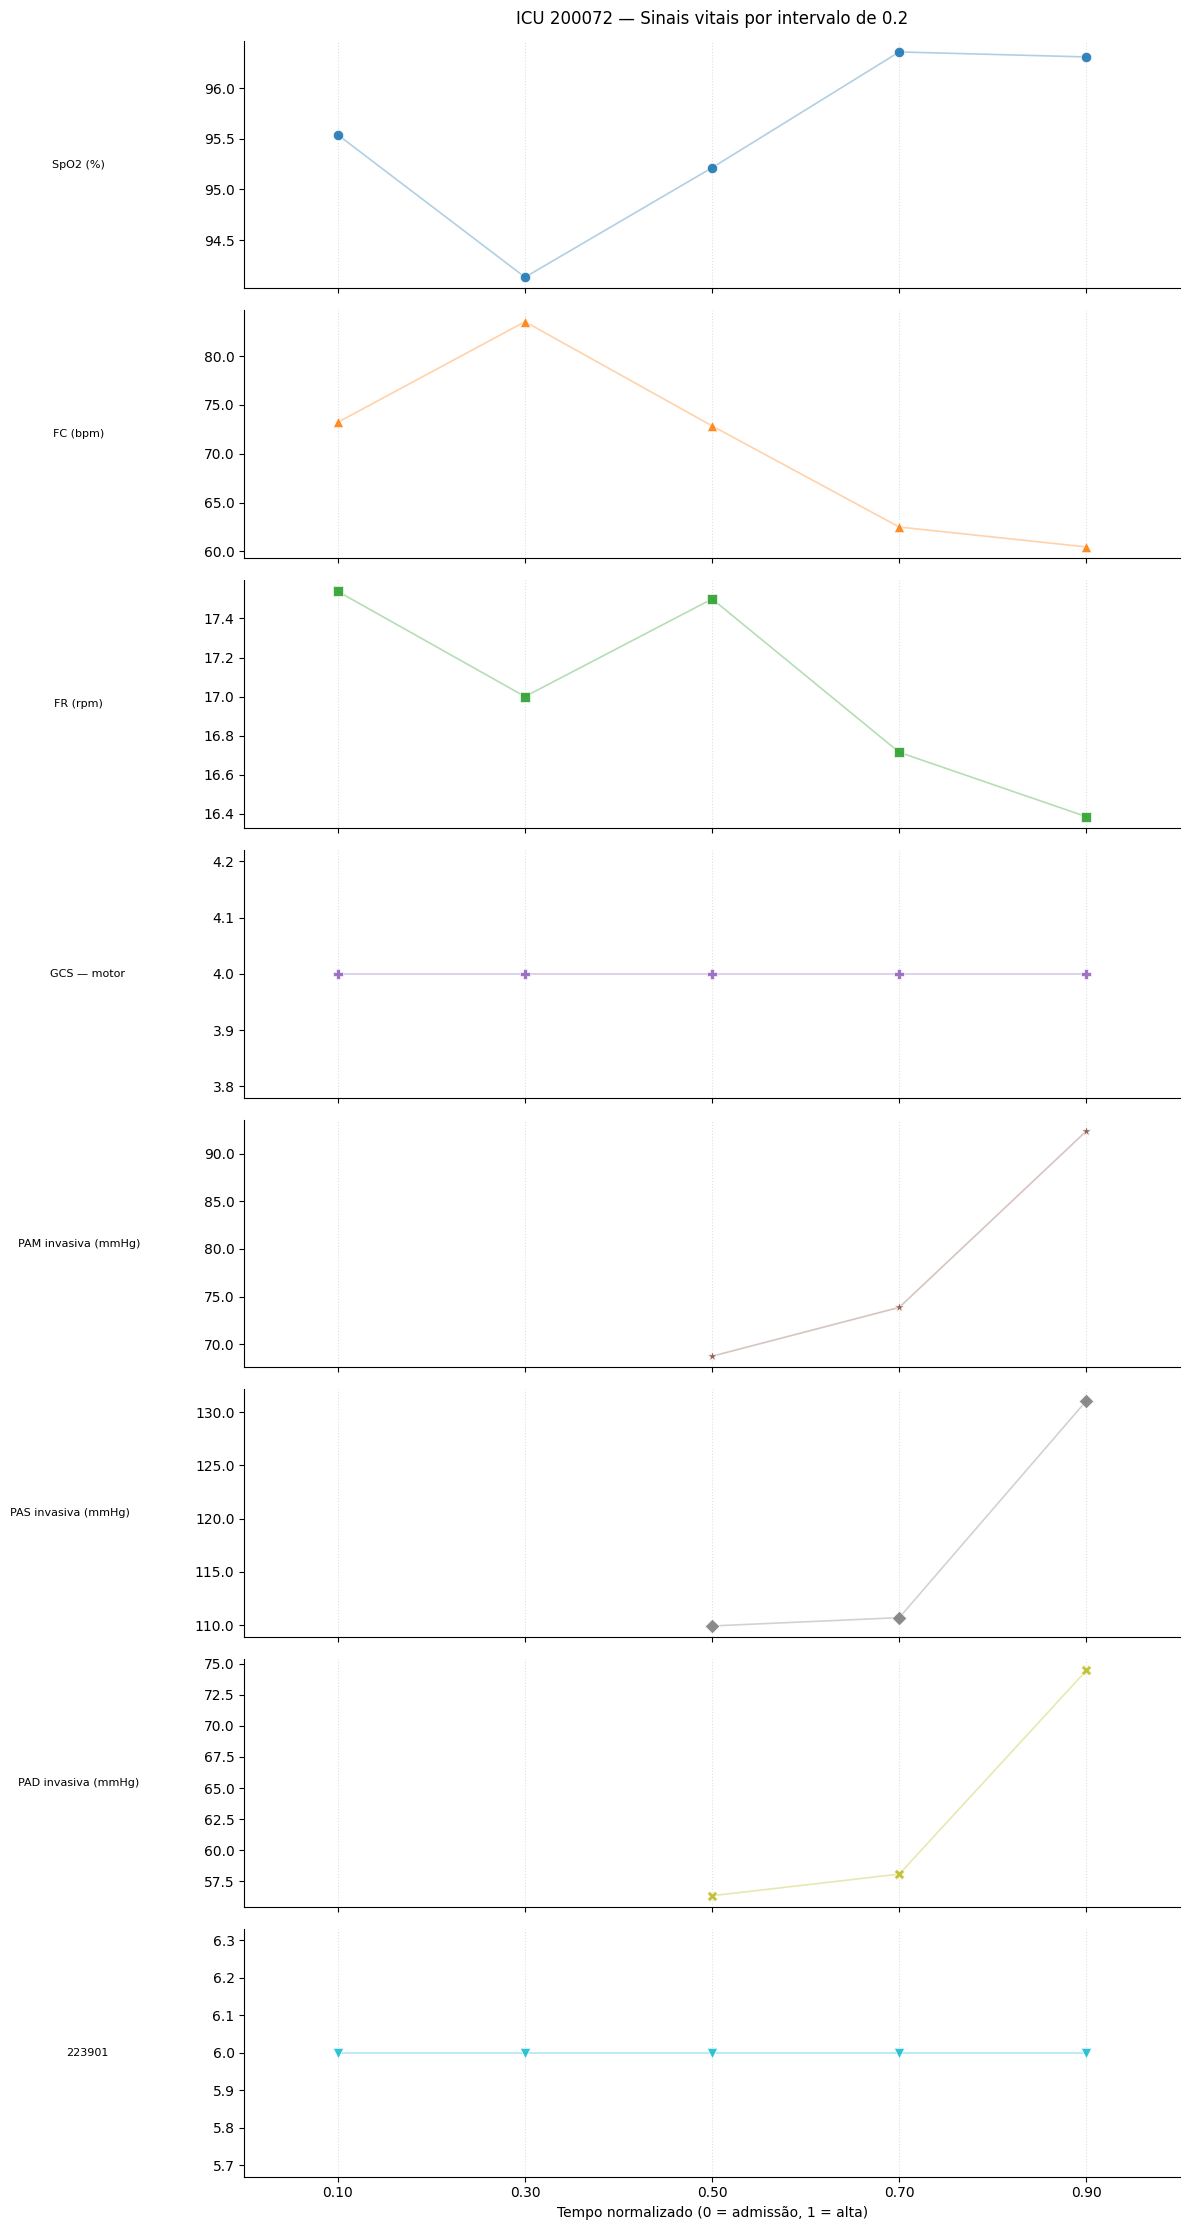

Gráfico guardado em viz_patient_scatter.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

ICUSTAY_ID_EXAMPLE = 200072
BIN_SIZE = 0.2

# --- Preparação ---
df_stay = df_chart.filter(col("ICUSTAY_ID") == ICUSTAY_ID_EXAMPLE) \
    .select("CHARTTIME", "ITEMID", "VALUENUM") \
    .dropna(subset=["VALUENUM", "CHARTTIME"]) \
    .toPandas()

df_stay["CHARTTIME"] = pd.to_datetime(df_stay["CHARTTIME"])
t_min = df_stay["CHARTTIME"].min()
t_max = df_stay["CHARTTIME"].max()
df_stay["time_frac"] = (df_stay["CHARTTIME"] - t_min) / (t_max - t_min)

# --- Aglomeração em bins ---
bins = np.arange(0, 1 + BIN_SIZE, BIN_SIZE)
df_stay["time_bin"] = pd.cut(df_stay["time_frac"], bins=bins, labels=np.round(bins[:-1], 2))

top_items = df_stay["ITEMID"].value_counts().head(8).index
df_filtered = df_stay[df_stay["ITEMID"].isin(top_items)]

df_agg = df_filtered.groupby(["time_bin", "ITEMID"], observed=True)["VALUENUM"] \
    .mean().reset_index()

# --- Scatter plot por subplots ---
markers = ["o", "^", "s", "P", "*", "D", "X", "v"]
colors = plt.cm.tab10(np.linspace(0, 1, len(top_items)))
bin_centers = np.round(bins[:-1] + BIN_SIZE / 2, 3)

fig, axes = plt.subplots(len(top_items), 1,
                          figsize=(12, 2.8 * len(top_items)),
                          sharex=True)

for ax, item, color, marker in zip(axes, top_items, colors, markers):
    sub = df_agg[df_agg["ITEMID"] == item].copy()
    x = sub["time_bin"].astype(float) + BIN_SIZE / 2

    ax.plot(x, sub["VALUENUM"], color=color, alpha=0.35, linewidth=1.2, zorder=1)
    ax.scatter(x, sub["VALUENUM"],
               color=color, marker=marker,
               s=55, alpha=0.9, zorder=2, edgecolors="white", linewidths=0.5)

    label = ITEM_LABELS.get(item, str(item))
    ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=90, va="center")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.4)

axes[-1].set_xlabel("Tempo normalizado (0 = admissão, 1 = alta)")
axes[-1].set_xticks(bin_centers)
axes[-1].set_xticklabels([f"{b:.2f}" for b in bin_centers])
axes[0].set_title(f"ICU {ICUSTAY_ID_EXAMPLE} — Sinais vitais por intervalo de {BIN_SIZE}", pad=12)

plt.tight_layout()
plt.savefig("viz_patient_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em viz_patient_scatter.png")

---
# Capítulo 3 — Pré-processamento

Nesta fase são aplicadas as transformações necessárias para converter os eventos clínicos brutos num dataset adequado para modelação.

As principais etapas são:

1. **Janela temporal** — selecção dos eventos registados nas primeiras 48 horas após admissão;
2. **Remoção de outliers** — aplicação dos limites IQR calculados na análise exploratória;
3. **Pivot dos dados** — transformação do formato longo para formato largo, com uma linha por `ICUSTAY_ID`;
4. **Feature engineering** — selecção dos ITEMIDs mais frequentes e agregação dos valores clínicos.

A janela de 48 horas representa um compromisso entre antecipação da decisão clínica e disponibilidade de informação suficiente para previsão.

In [17]:
# ============================================================
# RELOAD AUXILIARY TABLES — AUTO-FIND FILES
# ============================================================

from pathlib import Path

def find_file(filename, start_dir=Path(".")):
    matches = list(start_dir.resolve().rglob(filename))
    
    if len(matches) == 0:
        raise FileNotFoundError(f"Não encontrei {filename} dentro de {start_dir.resolve()}")
    
    if len(matches) > 1:
        print(f"Aviso: encontrei várias versões de {filename}. Vou usar a primeira:")
        for m in matches:
            print(" -", m)
    
    return matches[0]

items_path = find_file("D_ITEMS.csv.gz")
adm_path   = find_file("ADMISSIONS.csv.gz")
icu_path   = find_file("ICUSTAYS.csv.gz")

print("Paths encontrados:")
print("D_ITEMS:   ", items_path)
print("ADMISSIONS:", adm_path)
print("ICUSTAYS:  ", icu_path)

df_items = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(items_path.as_uri())
)

df_adm = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(adm_path.as_uri())
)

df_icu = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(icu_path.as_uri())
)

print("\nAuxiliary tables loaded.")
print("df_items:", df_items.count())
print("df_adm:", df_adm.count())
print("df_icu:", df_icu.count())

Paths encontrados:
D_ITEMS:    C:\Users\elman\Desktop\MIMIC-EDU-Machine-Learning-Pipeline-main\MIMIC-EDU-Machine-Learning-Pipeline-main\D_ITEMS.csv.gz
ADMISSIONS: C:\Users\elman\Desktop\MIMIC-EDU-Machine-Learning-Pipeline-main\MIMIC-EDU-Machine-Learning-Pipeline-main\ADMISSIONS.csv.gz
ICUSTAYS:   C:\Users\elman\Desktop\MIMIC-EDU-Machine-Learning-Pipeline-main\MIMIC-EDU-Machine-Learning-Pipeline-main\ICUSTAYS.csv.gz

Auxiliary tables loaded.
df_items: 12487
df_adm: 58976
df_icu: 61532


In [18]:
from pyspark.sql.functions import to_timestamp, unix_timestamp, col, min as spark_min
from pyspark.sql import Window
import pyspark.sql.functions as F

WINDOW_HOURS = 48

WINDOW_HOURS = 48

df_chart = df_chart.withColumn("CHARTTIME", to_timestamp("CHARTTIME"))

df_adm_ts = df_adm.select(
    col("HADM_ID").cast("int"),
    to_timestamp("ADMITTIME").alias("admit_time")
)

# Remover admit_time se já existir de execuções anteriores
if "admit_time" in df_chart.columns:
    df_chart = df_chart.drop("admit_time")

df_chart = df_chart.join(df_adm_ts, on="HADM_ID", how="left")

df_chart = df_chart.withColumn(
    "hours_from_admit",
    (unix_timestamp("CHARTTIME") - unix_timestamp("admit_time")) / 3600
)

df_window = df_chart.filter(
    col("hours_from_admit").isNotNull() &
    (col("hours_from_admit") >= 0) &
    (col("hours_from_admit") <= WINDOW_HOURS)
)
print(f"Janela {WINDOW_HOURS}h aplicada.")
print(f"Registos na janela: {df_window.count():,}")

Janela 48h aplicada.
Registos na janela: 85,615,538


### 3.2 Remoção de outliers por IQR

Os limites IQR calculados no Capítulo 2 são aplicados aqui, antes do pivot.
Registos fora dos limites são removidos — como a agregação posterior é uma média por estadia,
a perda de registos individuais não compromete a estrutura do dataset final.

In [19]:
from pyspark.sql import functions as F

item_bounds_list = [(int(item), float(v["lo"]), float(v["hi"])) for item, v in bounds.items()]

other_items = ~col("ITEMID").isin([b[0] for b in item_bounds_list])
within_bounds = other_items

for item_id, lo, hi in item_bounds_list:
    within_bounds = within_bounds | (
        (col("ITEMID") == item_id) & col("VALUENUM").between(lo, hi)
    )

df_window_clean = df_window.filter(within_bounds).cache()

n_before  = df_window.count()
n_after   = df_window_clean.count()
n_removed = n_before - n_after
print(f"Registos antes:   {n_before:,}")
print(f"Registos depois:  {n_after:,}")
print(f"Removidos:        {n_removed:,} ({n_removed/n_before*100:.2f}%)")

Registos antes:   85,615,538
Registos depois:  82,115,471
Removidos:        3,500,067 (4.09%)


### 3.3 Pivot — uma linha por ICUSTAY_ID

O pivot transforma o formato longo (um registo por evento) em formato largo (uma linha por estadia),
calculando a média de cada ITEMID nas primeiras 48h. Este é o formato esperado pelos modelos ML.

In [22]:
from pyspark.sql.functions import avg, desc

# --- 3.3 Seleccionar os 50 ITEMIDs mais frequentes após limpeza ---
top_items = df_window_clean.groupBy("ITEMID") \
    .count() \
    .orderBy(desc("count")) \
    .limit(50) \
    .select("ITEMID") \
    .rdd.flatMap(lambda x: x).collect()

print(f"Top 50 ITEMIDs: {top_items[:10]}...")

df_pivot = df_window_clean.filter(col("ITEMID").isin(top_items)) \
    .groupBy("ICUSTAY_ID") \
    .pivot("ITEMID", top_items) \
    .agg(avg("VALUENUM"))

n_rows = df_pivot.count()
n_cols = len(df_pivot.columns)
print(f"Shape do pivot: {n_rows:,} linhas x {n_cols} colunas")
print(f"Colunas nulas por coluna (amostra):")
df_pivot.select([
    F.sum(col(c).isNull().cast("int")).alias(c)
    for c in df_pivot.columns[1:6]
]).show()

Top 50 ITEMIDs: [211, 742, 618, 646, 220045, 220210, 220277, 1125, 159, 220048]...
Shape do pivot: 49,390 linhas x 51 colunas
Colunas nulas por coluna (amostra):
+-----+-----+-----+-----+------+
|  211|  742|  618|  646|220045|
+-----+-----+-----+-----+------+
|19011|26347|26396|26411| 30382|
+-----+-----+-----+-----+------+



---
## Capítulo 4 — Preparação dos Dados para ML

- **1:** Calcular o Target (variável a prever: lenght_of_stay)
- **2:** Remoção de missing values e normalização
- **3:** Split treino/teste por SUBJECT_ID
- **4:** Verificação da Análise


## 4.1 Cálculo do Target — Length of Stay em UCI

A variável alvo corresponde à duração da estadia em Unidade de Cuidados Intensivos, expressa em dias.

O target é calculado a partir da tabela `ICUSTAYS`, utilizando a diferença entre `INTIME` e `OUTTIME`.

Esta opção é mais adequada do que usar a tabela `ADMISSIONS`, uma vez que esta representa o internamento hospitalar total e pode incluir períodos fora da UCI.

In [23]:
from pyspark.sql.functions import to_timestamp, unix_timestamp, col, round as spark_round
import time

# Calcular LOS em dias a partir de ICUSTAYS (INTIME → OUTTIME)
# ICUSTAYS representa a estadia específica em UCI — correto para o enunciado.
# ADMISSIONS representaria o internamento hospitalar total (incorreto).
if df_icu is None:
    raise RuntimeError("ICUSTAYS.csv.gz não foi carregado — necessário para calcular o target UCI.")

df_los = df_icu.select(
    col("ICUSTAY_ID").cast("int"),
    col("HADM_ID").cast("int"),
    col("SUBJECT_ID").cast("int"),
    spark_round(
        (unix_timestamp(to_timestamp("OUTTIME")) - unix_timestamp(to_timestamp("INTIME"))) / 86400,
        2
    ).alias("los_days")
).filter(
    col("los_days").isNotNull() &
    (col("los_days") > 0) &
    (col("los_days") < 365)  # remover estadias implausíveis
)

print(f"Estadias UCI com LOS calculado: {df_los.count():,}")
df_los.describe("los_days").show()


Estadias UCI com LOS calculado: 61,489
+-------+-----------------+
|summary|         los_days|
+-------+-----------------+
|  count|            61489|
|   mean|4.920621737221236|
| stddev|9.640654915561232|
|    min|             0.01|
|    max|           173.07|
+-------+-----------------+



## 4.2 Imputação de Valores em Falta

O pivot gera muitos valores nulos porque nem todos os doentes têm registos de todos os ITEMIDs.

A imputação é realizada através da mediana de cada coluna, por ser uma medida mais robusta do que a média em distribuições assimétricas e com outliers.

A normalização não é aplicada nesta secção. Para evitar *data leakage*, o `StandardScaler` é ajustado apenas após o split treino/teste, utilizando exclusivamente os dados de treino.

In [24]:
import pandas as pd
import numpy as np
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql.functions import col

# Juntar pivot com LOS via ICUSTAY_ID (join direto — df_los agora tem ICUSTAY_ID)
df_ml = df_pivot \
    .join(df_los.select("ICUSTAY_ID", "HADM_ID", "SUBJECT_ID", "los_days"), on="ICUSTAY_ID", how="inner")

print(f"Dataset ML: {df_ml.count():,} linhas x {len(df_ml.columns)} colunas")

# Colunas de features (todos os ITEMIDs — excluir IDs e target)
id_cols      = ["ICUSTAY_ID", "HADM_ID", "SUBJECT_ID", "los_days"]
feature_cols = [c for c in df_ml.columns if c not in id_cols]
print(f"Features: {len(feature_cols)} ITEMIDs")


Dataset ML: 49,389 linhas x 54 colunas
Features: 50 ITEMIDs


In [25]:

import pyspark.sql.functions as F
from pyspark.sql.functions import col

quantiles = df_ml.approxQuantile(feature_cols, [0.5], 0.01)

median_values = {}
cols_all_null = []

for c, q in zip(feature_cols, quantiles):
    if q and len(q) > 0:
        median_values[c] = float(q[0])
    else:
        median_values[c] = 0.0
        cols_all_null.append(c)

print(f"Medianas calculadas para {len(median_values)} colunas.")

if cols_all_null:
    print(f"Colunas completamente nulas com fallback=0: {len(cols_all_null)}")
    print(cols_all_null[:10])

df_ml_imputed = df_ml

for c in feature_cols:
    df_ml_imputed = df_ml_imputed.withColumn(
        c,
        F.when(col(c).isNull(), F.lit(median_values[c])).otherwise(col(c))
    )

null_counts = df_ml_imputed.select([
    F.sum(col(c).isNull().cast("int")).alias(c)
    for c in feature_cols
]).toPandas()

total_nulls = null_counts.values.sum()

print(f"Nulos após imputação: {total_nulls} (esperado: 0)")

Medianas calculadas para 50 colunas.
Colunas completamente nulas com fallback=0: 16
['1125', '159', '220048', '227969', '224650', '1484', '1337', '674', '432', '31']
Nulos após imputação: 0 (esperado: 0)


In [26]:
# Nota: a normalização (StandardScaler) é aplicada APÓS o split treino/teste
# na célula 4.3, para evitar data leakage (o scaler não deve "ver" o conjunto de teste).
print("Imputação concluída. Split e normalização são efectuados na secção 4.3.")


Imputação concluída. Split e normalização são efectuados na secção 4.3.


### 4.3 Split treino/teste por SUBJECT_ID + Normalização

O split é feito por `SUBJECT_ID` — não por linha aleatória — para evitar **data leakage**:
o mesmo doente pode ter múltiplas estadias UCI, e se uma for para treino e outra para teste
o modelo "vê" o doente antes de prever, inflacionando artificialmente as métricas.

A normalização com `StandardScaler` é aplicada **depois** do split: o scaler é ajustado
(`fit`) exclusivamente nos dados de treino e depois aplicado (`transform`) ao treino e
ao teste separadamente. Aplicar o scaler antes do split constituiria data leakage estatístico.


In [27]:
import time
from pyspark.sql.functions import col
import pyspark.sql.functions as F
from sklearn.preprocessing import StandardScaler as SklearnScaler

TEST_RATIO = 0.2
SEED       = 42

# --- 1. Split por SUBJECT_ID (evita data leakage entre estadias do mesmo doente) ---
subject_ids = df_ml_imputed.select("SUBJECT_ID").distinct()
train_subj, test_subj = subject_ids.randomSplit([1 - TEST_RATIO, TEST_RATIO], seed=SEED)

df_train_spark = df_ml_imputed.join(train_subj, on="SUBJECT_ID", how="inner").cache()
df_test_spark  = df_ml_imputed.join(test_subj,  on="SUBJECT_ID", how="inner").cache()

n_train = df_train_spark.count()
n_test  = df_test_spark.count()
print(f"Treino: {n_train:,} estadias ({n_train/(n_train+n_test)*100:.1f}%)")
print(f"Teste:  {n_test:,} estadias ({n_test/(n_train+n_test)*100:.1f}%)")

# --- 2. Converter para pandas ---
X_train = df_train_spark.select(feature_cols).toPandas()
y_train = df_train_spark.select("los_days").toPandas().values.ravel()

X_test  = df_test_spark.select(feature_cols).toPandas()
y_test  = df_test_spark.select("los_days").toPandas().values.ravel()

# --- 3. Normalização: fit APENAS no treino, transform em ambos ---
# Aplicar o scaler antes do split seria data leakage estatístico.
scaler    = SklearnScaler()
X_train   = scaler.fit_transform(X_train)   # fit + transform no treino
X_test    = scaler.transform(X_test)        # só transform no teste

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print("Split e normalização concluídos sem data leakage.")


Treino: 39,535 estadias (80.0%)
Teste:  9,854 estadias (20.0%)

X_train: (39535, 50)  |  X_test: (9854, 50)
y_train: (39535,)  |  y_test: (9854,)
Split e normalização concluídos sem data leakage.


### 4.4 Verificação

In [28]:
# A verificação da distribuição do LOS e os histogramas de treino/teste
# estão incluídos na célula 4.3 (Split + Normalização).
# Esta célula é mantida para eventuais análises adicionais ao target.

import pandas as pd
print("\nEstatísticas do target (LOS UCI em dias):")
print(pd.DataFrame({
    "Treino": pd.Series(y_train).describe(),
    "Teste":  pd.Series(y_test).describe()
}).round(2))



Estatísticas do target (LOS UCI em dias):
         Treino    Teste
count  39535.00  9854.00
mean       4.95     4.93
std        9.99     9.79
min        0.01     0.01
25%        1.09     1.11
50%        2.04     2.03
75%        4.32     4.45
max      171.66   153.97


---
# Capítulo 5 — Treino e Validação dos Modelos

Após a construção do dataset final e imputação dos valores em falta, procede-se ao desenvolvimento dos modelos de Machine Learning para previsão do *Length of Stay (LOS)* em Unidade de Cuidados Intensivos.

Foram seleccionados dois algoritmos amplamente utilizados em problemas de regressão com dados tabulares:

- **Random Forest Regressor**, utilizado como modelo baseline devido à sua robustez, capacidade de generalização e interpretabilidade;
- **XGBoost Regressor**, um algoritmo baseado em *Gradient Boosting* amplamente reconhecido pelo seu elevado desempenho em problemas de previsão com dados estruturados.

Neste capítulo são descritas as etapas de preparação dos dados para treino, a divisão dos conjuntos de treino e teste, o treino dos modelos candidatos e o processo de optimização dos respectivos hiperparâmetros.

A avaliação do desempenho dos modelos e a análise detalhada dos resultados obtidos serão apresentadas no capítulo seguinte.

## 5.1 Caracterização do Dataset

A Tabela seguinte resume as principais características do dataset final utilizado para treino dos modelos.

Foram consideradas apenas observações pertencentes à janela temporal inicial definida anteriormente, sendo posteriormente efectuado o processo de imputação dos valores em falta.

A variável alvo corresponde ao número de dias de internamento em Unidade de Cuidados Intensivos (*Length of Stay*).

In [29]:
# ============================================================
# 5.1 — DATASET CHARACTERIZATION
# ============================================================

import pandas as pd
from pyspark.sql.functions import avg, expr

n_rows = df_ml_imputed.count()

n_patients = (
    df_ml_imputed
    .select("SUBJECT_ID")
    .distinct()
    .count()
)

n_icustays = (
    df_ml_imputed
    .select("ICUSTAY_ID")
    .distinct()
    .count()
)

mean_los = (
    df_ml_imputed
    .select(avg("los_days"))
    .first()[0]
)

median_los = (
    df_ml_imputed
    .approxQuantile("los_days", [0.5], 0.01)[0]
)

summary_table = pd.DataFrame({
    "Metric": [
        "Patients",
        "ICU Stays",
        "Features",
        "Mean LOS (days)",
        "Median LOS (days)"
    ],
    "Value": [
        n_patients,
        n_icustays,
        len(feature_cols),
        round(mean_los, 2),
        round(median_los, 2)
    ]
})

summary_table

,Metric,Value
0,Patients,40984.00
1,ICU Stays,49389.00
2,Features,50.00
3,Mean LOS (days),4.95
4,Median LOS (days),2.02


## 5.2 Dados de Treino e Teste

O split treino/teste e a normalização foram efectuados na secção 4.3, garantindo que:
- o split é feito por `SUBJECT_ID` (sem data leakage entre estadias do mesmo doente);
- o `StandardScaler` foi ajustado exclusivamente nos dados de treino.

Os arrays `X_train`, `X_test`, `y_train` e `y_test` estão prontos para treino.


X_train: (39535, 50)
X_test : (9854, 50)
y_train: (39535,)
y_test : (9854,)


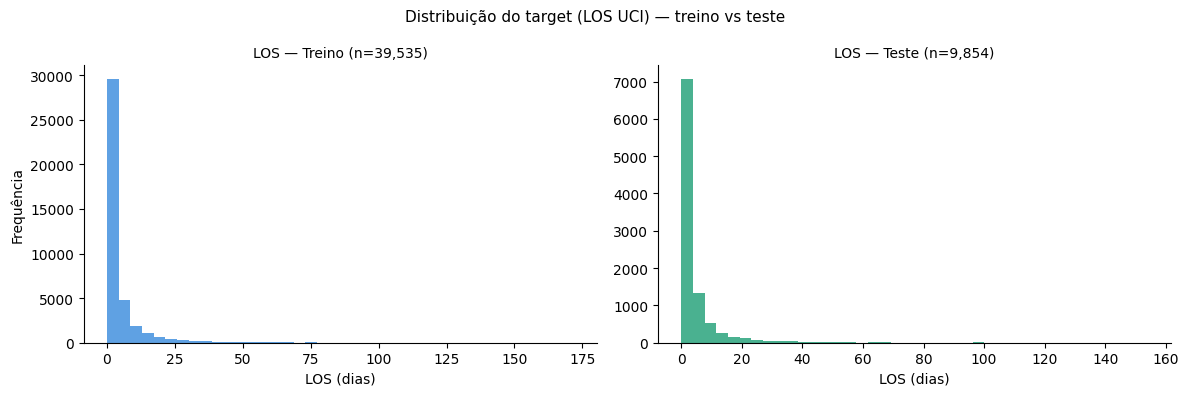

In [30]:
import matplotlib.pyplot as plt

# Verificação dos arrays prontos para treino
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

# Distribuição do target em treino vs teste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=40, alpha=0.8, color="#378ADD", edgecolor="none")
axes[0].set_title(f"LOS — Treino (n={len(y_train):,})", fontsize=10)
axes[0].set_xlabel("LOS (dias)"); axes[0].set_ylabel("Frequência")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(y_test, bins=40, alpha=0.8, color="#1D9E75", edgecolor="none")
axes[1].set_title(f"LOS — Teste (n={len(y_test):,})", fontsize=10)
axes[1].set_xlabel("LOS (dias)")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribuição do target (LOS UCI) — treino vs teste", fontsize=11)
plt.tight_layout()
plt.savefig("viz_los_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


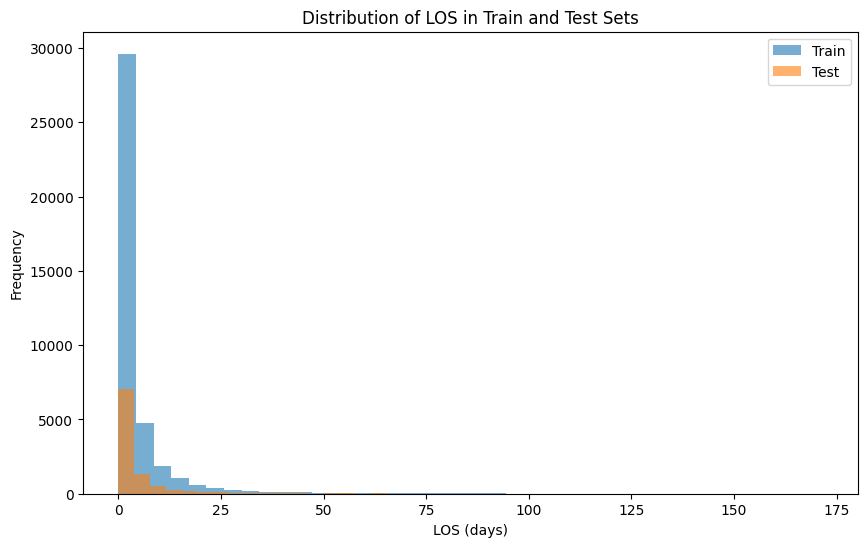

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    y_train,
    bins=40,
    alpha=0.6,
    label="Train"
)

plt.hist(
    y_test,
    bins=40,
    alpha=0.6,
    label="Test"
)

plt.xlabel("LOS (days)")
plt.ylabel("Frequency")
plt.title("Distribution of LOS in Train and Test Sets")
plt.legend()

plt.show()

## 5.3 Random Forest Baseline

O Random Forest foi utilizado como modelo de referência devido à sua robustez perante dados ruidosos e à sua capacidade de capturar relações não lineares sem necessidade de pressupostos fortes sobre os dados.

In [32]:
# ============================================================
# 5.3 — RANDOM FOREST BASELINE
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import time

t0 = time.time()

rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

rf_time = time.time() - t0

rf_pred = rf_baseline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

rf_baseline_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [rf_mae, rf_rmse, rf_r2]
})

rf_baseline_results

,Metric,Value
0,MAE,3.996246
1,RMSE,9.077429
2,R²,0.140174


## 5.4 RANDOM FOREST TUNING

In [34]:
# ============================================================
# 5.4 — RANDOM FOREST TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV
import time

rf_grid = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5]
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

t0_rf_search = time.time()
rf_search.fit(X_train, y_train)
rf_search_time = time.time() - t0_rf_search
print(f"RF GridSearchCV concluído em {rf_search_time:.1f}s ({rf_search_time/60:.1f} min)")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
RF GridSearchCV concluído em 957.8s (16.0 min)


In [35]:
rf_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 200}

In [36]:
# ============================================================
# 5.4 — TOP 10 RANDOM FOREST CONFIGURATIONS
# ============================================================

rf_cv = pd.DataFrame(rf_search.cv_results_)

top10_rf = (
    rf_cv
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

top10_rf["RMSE"] = -top10_rf["mean_test_score"]

top10_rf["n_estimators"] = top10_rf["params"].apply(lambda x: x["n_estimators"])
top10_rf["max_depth"] = top10_rf["params"].apply(lambda x: x["max_depth"])
top10_rf["min_samples_leaf"] = top10_rf["params"].apply(lambda x: x["min_samples_leaf"])
top10_rf["min_samples_split"] = top10_rf["params"].apply(lambda x: x["min_samples_split"])

top10_rf = top10_rf[
    [
        "rank_test_score",
        "RMSE",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split"
    ]
]

top10_rf.columns = [
    "Rank",
    "RMSE",
    "Trees",
    "Max Depth",
    "Min Leaf",
    "Min Split"
]

top10_rf.reset_index(drop=True, inplace=True)

top10_rf

,Rank,RMSE,Trees,Max Depth,Min Leaf,Min Split
0,1,8.774927,200,10,2,5
1,2,8.777163,500,10,2,5
2,3,8.778435,200,10,2,2
3,4,8.781493,500,10,2,2
4,5,8.805881,200,10,1,5
5,6,8.811525,500,10,1,5
6,7,8.829879,200,10,1,2
7,8,8.836752,500,10,1,2
8,9,8.957648,500,20,2,5
9,10,8.967103,200,20,2,5


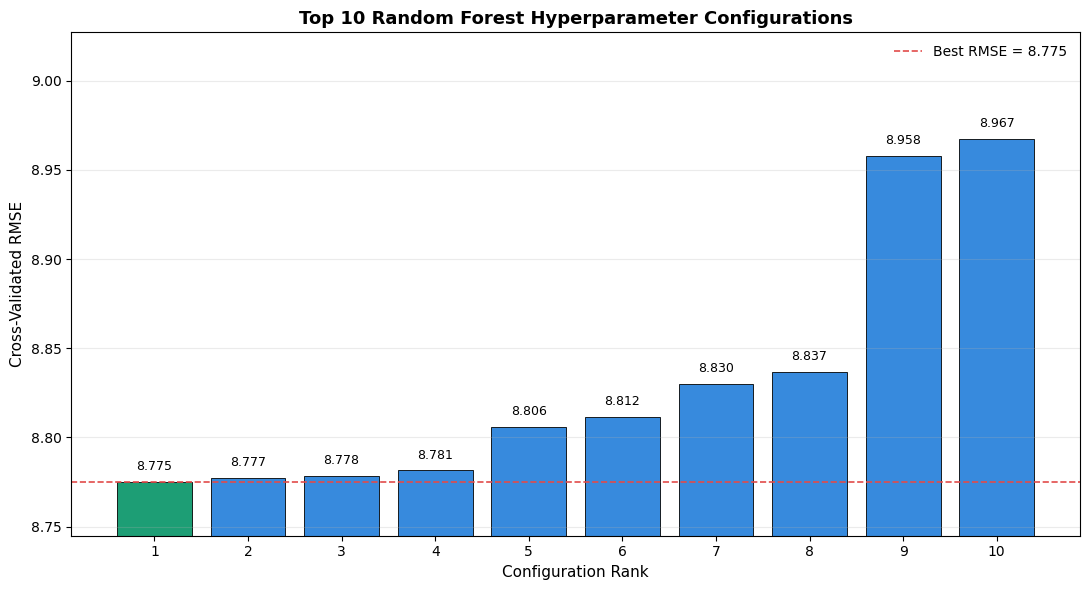

In [37]:
# ============================================================
# 5.4 — TOP CONFIGURATIONS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = top10_rf.copy()

# Highlight best configuration
bar_colors = [
    "#1D9E75" if rank == 1 else "#378ADD"
    for rank in plot_df["Rank"]
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    plot_df["Rank"].astype(str),
    plot_df["RMSE"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

# Add value labels above bars
for bar, rmse in zip(bars, plot_df["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{rmse:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Add reference line for best RMSE
best_rmse = plot_df["RMSE"].min()

plt.axhline(
    best_rmse,
    linestyle="--",
    linewidth=1.2,
    color="#E24B4A",
    label=f"Best RMSE = {best_rmse:.3f}"
)

plt.xlabel("Configuration Rank", fontsize=11)
plt.ylabel("Cross-Validated RMSE", fontsize=11)
plt.title(
    "Top 10 Random Forest Hyperparameter Configurations",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(
    plot_df["RMSE"].min() - 0.03,
    plot_df["RMSE"].max() + 0.06
)

plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("viz_rf_top10_configurations.png", dpi=150, bbox_inches="tight")
plt.show()

### Análise dos Resultados da Optimização do Random Forest

A optimização dos hiperparâmetros foi realizada através de uma pesquisa exaustiva (*Grid Search*) combinada com validação cruzada de 5 folds.

A Tabela anterior apresenta as dez melhores configurações identificadas durante o processo de optimização, ordenadas segundo o valor de RMSE obtido na validação cruzada.

Observa-se que as melhores configurações apresentam valores de desempenho muito próximos entre si, evidenciando uma elevada estabilidade do algoritmo relativamente às combinações de hiperparâmetros avaliadas.

Em particular, verifica-se que:

- As melhores soluções utilizam profundidades máximas moderadas (`max_depth = 10`);
- Valores de `min_samples_leaf = 2` tendem a produzir melhor capacidade de generalização;
- O aumento excessivo da profundidade das árvores não resultou em melhorias significativas de desempenho;
- As diferenças entre as dez melhores configurações são reduzidas, sugerindo baixa sensibilidade do modelo aos hiperparâmetros testados.

Este comportamento é consistente com a literatura, uma vez que os modelos Random Forest tendem a apresentar elevada robustez e estabilidade mesmo perante pequenas alterações na configuração interna.

A melhor configuração obtida será utilizada nas fases seguintes de avaliação e comparação com o modelo XGBoost.

## 5.5 — Modelo XGBoost

Após a avaliação do modelo Random Forest, foi seleccionado o algoritmo XGBoost (*Extreme Gradient Boosting*) como segundo modelo candidato.

O XGBoost é actualmente uma das técnicas mais utilizadas em problemas de Machine Learning envolvendo dados tabulares, devido à sua elevada capacidade preditiva, robustez perante dados ruidosos e eficiência computacional.

Ao contrário do Random Forest, que constrói árvores de forma independente, o XGBoost utiliza um processo sequencial de *boosting*, onde cada nova árvore procura corrigir os erros cometidos pelas árvores anteriores.

Nesta fase é treinado um modelo baseline utilizando parâmetros standard, permitindo estabelecer um ponto de referência antes da optimização de hiperparâmetros.

In [38]:
from xgboost import XGBRegressor

t0 = time.time()

xgb_baseline = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)

xgb_time = time.time() - t0

xgb_pred = xgb_baseline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

xgb_baseline_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [xgb_mae, xgb_rmse, xgb_r2]
})

xgb_baseline_results

,Metric,Value
0,MAE,4.038653
1,RMSE,8.598035
2,R²,0.228593


### Resultados do Modelo Baseline

A Tabela anterior apresenta os resultados obtidos pelo modelo XGBoost sem optimização de hiperparâmetros.

A comparação preliminar com o Random Forest permite avaliar se a utilização de técnicas de *gradient boosting* proporciona ganhos de desempenho na previsão do tempo de internamento em Unidade de Cuidados Intensivos.

Contudo, os parâmetros utilizados nesta fase não foram optimizados, pelo que os resultados representam apenas uma configuração inicial do algoritmo.

## 5.6 — Optimização de Hiperparâmetros do XGBoost

O desempenho do XGBoost depende fortemente da escolha dos seus hiperparâmetros.

Entre os parâmetros mais relevantes encontram-se:

- Número de árvores (*n_estimators*);
- Profundidade máxima das árvores (*max_depth*);
- Taxa de aprendizagem (*learning_rate*);
- Percentagem de observações utilizadas em cada árvore (*subsample*);
- Percentagem de variáveis consideradas em cada divisão (*colsample_bytree*).

Em vez de utilizar uma pesquisa exaustiva (*Grid Search*), foi adoptado o método **Randomized Search Cross Validation**, que permite explorar uma região mais ampla do espaço de procura com menor custo computacional.

A optimização foi efectuada utilizando validação cruzada de 5 folds e a métrica RMSE como critério principal de selecção.

In [39]:
from sklearn.model_selection import RandomizedSearchCV
import time

xgb_param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

t0_xgb_search = time.time()
xgb_search.fit(X_train, y_train)
xgb_search_time = time.time() - t0_xgb_search
print(f"XGB RandomizedSearchCV concluído em {xgb_search_time:.1f}s ({xgb_search_time/60:.1f} min)")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGB RandomizedSearchCV concluído em 34.8s (0.6 min)


### Melhor Configuração Encontrada

A optimização identificou a combinação de hiperparâmetros apresentada anteriormente como a mais adequada para o conjunto de treino.

Ao contrário do Random Forest, cuja optimização foi realizada através de uma pesquisa exaustiva (`GridSearchCV`), o modelo XGBoost foi optimizado utilizando `RandomizedSearchCV`.

Esta abordagem foi escolhida devido à dimensão do espaço de hiperparâmetros do XGBoost, onde uma pesquisa exaustiva exigiria um número muito elevado de combinações e um custo computacional significativamente superior.

A pesquisa aleatória permite explorar diferentes regiões do espaço de procura de forma eficiente, sendo amplamente utilizada na literatura para optimização de modelos complexos.

A utilização de validação cruzada com 5 folds reduz o risco de sobreajuste (*overfitting*) aos dados de treino e fornece uma estimativa mais robusta da capacidade de generalização do modelo.

A melhor configuração encontrada será utilizada para treinar o modelo final, posteriormente avaliado no conjunto de teste independente.

In [40]:
# ============================================================
# 5.6 — TOP 10 XGBOOST CONFIGURATIONS
# ============================================================

xgb_cv = pd.DataFrame(xgb_search.cv_results_)

top10_xgb = (
    xgb_cv
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

top10_xgb["RMSE"] = -top10_xgb["mean_test_score"]

top10_xgb["n_estimators"] = top10_xgb["params"].apply(lambda x: x["n_estimators"])
top10_xgb["max_depth"] = top10_xgb["params"].apply(lambda x: x["max_depth"])
top10_xgb["learning_rate"] = top10_xgb["params"].apply(lambda x: x["learning_rate"])
top10_xgb["subsample"] = top10_xgb["params"].apply(lambda x: x["subsample"])
top10_xgb["colsample_bytree"] = top10_xgb["params"].apply(lambda x: x["colsample_bytree"])

top10_xgb = top10_xgb[
    [
        "rank_test_score",
        "RMSE",
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree"
    ]
]

top10_xgb.columns = [
    "Rank",
    "RMSE",
    "Trees",
    "Max Depth",
    "Learning Rate",
    "Subsample",
    "Colsample Bytree"
]

top10_xgb.reset_index(drop=True, inplace=True)

top10_xgb

,Rank,RMSE,Trees,Max Depth,Learning Rate,Subsample,Colsample Bytree
0,1,8.878842,300,4,0.05,0.7,0.7
1,2,8.879555,500,10,0.01,0.7,0.7
2,3,8.885844,500,4,0.03,0.7,0.7
3,4,8.886329,300,6,0.01,0.7,0.7
4,5,8.889331,300,6,0.01,0.7,0.8
5,6,8.890383,300,6,0.01,0.8,0.8
6,7,8.890659,300,4,0.03,0.7,0.8
7,8,8.892292,500,4,0.05,0.7,0.7
8,9,8.898962,500,4,0.01,0.8,0.8
9,10,8.910809,300,10,0.01,1.0,0.8


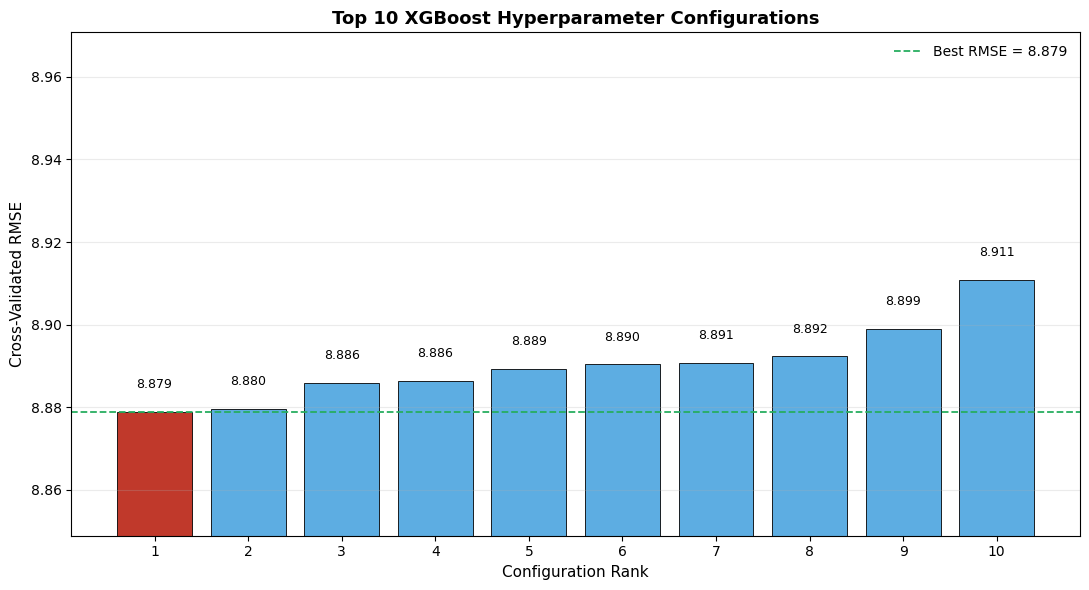

In [41]:
# ============================================================
# 5.6 — TOP XGBOOST CONFIGURATIONS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = top10_xgb.copy()

# Highlight best configuration
bar_colors = [
    "#C0392B" if rank == 1 else "#5DADE2"
    for rank in plot_df["Rank"]
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    plot_df["Rank"].astype(str),
    plot_df["RMSE"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

# RMSE labels
for bar, rmse in zip(bars, plot_df["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{rmse:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Best RMSE reference line
best_rmse = plot_df["RMSE"].min()

plt.axhline(
    best_rmse,
    linestyle="--",
    linewidth=1.3,
    color="#27AE60",
    label=f"Best RMSE = {best_rmse:.3f}"
)

plt.xlabel("Configuration Rank", fontsize=11)
plt.ylabel("Cross-Validated RMSE", fontsize=11)

plt.title(
    "Top 10 XGBoost Hyperparameter Configurations",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(
    plot_df["RMSE"].min() - 0.03,
    plot_df["RMSE"].max() + 0.06
)

plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "viz_xgb_top10_configurations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Análise dos Resultados da Optimização do XGBoost

A tabela anterior apresenta as dez melhores configurações avaliadas durante a optimização do XGBoost, ordenadas pelo RMSE médio obtido em validação cruzada.

Ao contrário do Random Forest, cuja optimização foi efectuada através de `GridSearchCV`, o XGBoost foi optimizado com `RandomizedSearchCV`, permitindo explorar um espaço de hiperparâmetros mais amplo com menor custo computacional.

Os hiperparâmetros avaliados controlam aspectos importantes do modelo:

- `n_estimators` define o número de árvores;
- `max_depth` controla a complexidade individual de cada árvore;
- `learning_rate` regula a contribuição de cada nova árvore;
- `subsample` controla a proporção de observações usada em cada iteração;
- `colsample_bytree` controla a proporção de variáveis considerada por árvore.

A melhor configuração encontrada será utilizada no capítulo seguinte para comparação final com os modelos Random Forest.

## 5.7 Comparação da Optimização de Hiperparâmetros

Após a optimização individual dos modelos Random Forest e XGBoost, é útil comparar o comportamento dos dois processos de pesquisa.

Embora os hiperparâmetros dos dois algoritmos não sejam directamente equivalentes, a comparação do melhor RMSE em validação cruzada permite avaliar qual das abordagens apresentou melhor desempenho durante a fase de validação.

Esta análise também permite comparar o custo computacional de cada processo de optimização.

In [42]:
# ============================================================
# 5.7 — HYPERPARAMETER OPTIMIZATION COMPARISON
# ============================================================

hyperparam_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Search Method": ["GridSearchCV", "RandomizedSearchCV"],
    "Best CV RMSE": [
        -rf_search.best_score_,
        -xgb_search.best_score_
    ],
    "Search Time (min)": [
        rf_search_time / 60,
        xgb_search_time / 60
    ],
    "Best Parameters": [
        rf_search.best_params_,
        xgb_search.best_params_
    ]
})

hyperparam_comparison

,Model,Search Method,Best CV RMSE,Search Time (min),Best Parameters
0,Random Forest,GridSearchCV,8.774927,15.963776,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."
1,XGBoost,RandomizedSearchCV,8.878842,0.579372,"{'subsample': 0.7, 'n_estimators': 300, 'max_d..."


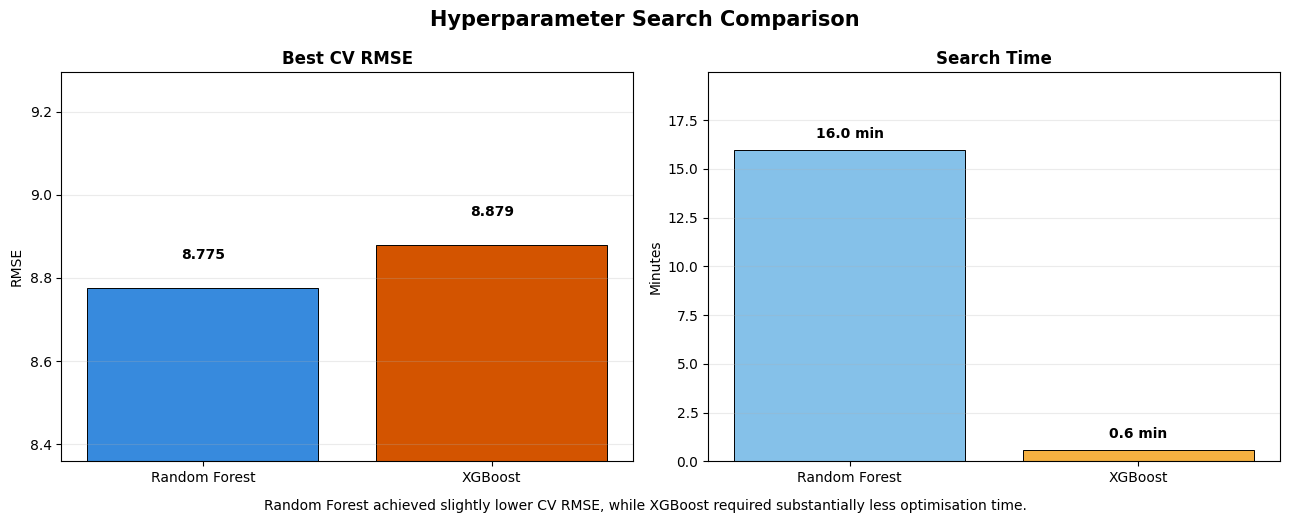

In [43]:
# ============================================================
# 5.7 — HYPERPARAMETER SEARCH COMPARISON — CLEAN VERSION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = hyperparam_comparison.copy()

models = plot_df["Model"].tolist()
rmse_values = plot_df["Best CV RMSE"].values
time_values = plot_df["Search Time (min)"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ------------------------------------------------------------
# Plot 1 — Best CV RMSE
# ------------------------------------------------------------

bars_rmse = axes[0].bar(
    models,
    rmse_values,
    color=["#378ADD", "#D35400"],
    edgecolor="black",
    linewidth=0.7
)

axes[0].set_title("Best CV RMSE", fontsize=12, fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.25)

rmse_margin = (rmse_values.max() - rmse_values.min()) * 4
if rmse_margin == 0:
    rmse_margin = 0.2

axes[0].set_ylim(
    rmse_values.min() - rmse_margin,
    rmse_values.max() + rmse_margin
)

for bar, value in zip(bars_rmse, rmse_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + rmse_margin * 0.15,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Plot 2 — Search time
# ------------------------------------------------------------

bars_time = axes[1].bar(
    models,
    time_values,
    color=["#85C1E9", "#F5B041"],
    edgecolor="black",
    linewidth=0.7
)

axes[1].set_title("Search Time", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Minutes")
axes[1].grid(axis="y", alpha=0.25)

axes[1].set_ylim(0, time_values.max() * 1.25)

for bar, value in zip(bars_time, time_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + time_values.max() * 0.03,
        f"{value:.1f} min",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Global title
# ------------------------------------------------------------

fig.suptitle(
    "Hyperparameter Search Comparison",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.5,
    -0.02,
    "Random Forest achieved slightly lower CV RMSE, while XGBoost required substantially less optimisation time.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig("viz_hyperparameter_search_comparison_clean.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussão da Comparação

A comparação entre os processos de optimização mostra o compromisso entre desempenho preditivo e custo computacional.

O Random Forest foi optimizado através de uma pesquisa exaustiva, enquanto o XGBoost utilizou pesquisa aleatória devido ao maior número de hiperparâmetros relevantes.

O melhor RMSE em validação cruzada permite comparar directamente a qualidade das melhores configurações encontradas. Por outro lado, o tempo de pesquisa evidencia o custo computacional associado a cada abordagem.

Esta comparação justifica a utilização de estratégias de optimização diferentes para cada modelo, equilibrando rigor experimental e viabilidade computacional.

---
# Capítulo 6 — Análise de Resultados

Após o treino e optimização dos modelos apresentados no capítulo anterior, procede-se à análise detalhada dos resultados obtidos no conjunto de teste independente.

O objectivo desta análise consiste em avaliar a capacidade dos modelos em prever o tempo de internamento em UCI e identificar as principais limitações associadas à previsão deste fenómeno clínico complexo.

A avaliação será feita através de métricas quantitativas, visualizações gráficas e análise dos erros de previsão.

As métricas principais utilizadas são:

- **MAE** (*Mean Absolute Error*) — erro médio absoluto em dias;
- **MedianAE** (*Median Absolute Error*) — erro mediano absoluto, mais robusto a outliers;
- **RMSE** (*Root Mean Squared Error*) — penaliza mais fortemente erros grandes;
- **R²** — proporção da variância explicada pelo modelo.

In [44]:
# Escolher explicitamente o melhor modelo da sessão atual
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Reavaliar ambos no mesmo X_test/y_test atual
rf_pred_final = best_rf.predict(X_test)
xgb_pred_final = best_xgb.predict(X_test)

rf_final = {
    "Model": "Random Forest Tuned",
    "MAE": mean_absolute_error(y_test, rf_pred_final),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred_final)),
    "R2": r2_score(y_test, rf_pred_final)
}

xgb_final = {
    "Model": "XGBoost Tuned",
    "MAE": mean_absolute_error(y_test, xgb_pred_final),
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred_final)),
    "R2": r2_score(y_test, xgb_pred_final)
}

final_results = pd.DataFrame([rf_final, xgb_final])
final_results

,Model,MAE,RMSE,R2
0,Random Forest Tuned,3.905558,8.363342,0.270131
1,XGBoost Tuned,4.003018,8.553961,0.236481


In [45]:
if xgb_final["RMSE"] <= rf_final["RMSE"]:
    best_model = best_xgb
    best_model_name = "XGBoost Tuned"
    best_pred = xgb_pred_final
else:
    best_model = best_rf
    best_model_name = "Random Forest Tuned"
    best_pred = rf_pred_final

print(f"Best model: {best_model_name}")

Best model: Random Forest Tuned


In [46]:
# ============================================================
# FINAL MODEL OBJECTS FROM CHAPTER 5
# ============================================================

rf_best = rf_search.best_estimator_
xgb_best = xgb_search.best_estimator_

print("RF best params:")
print(rf_search.best_params_)

print("\nXGB best params:")
print(xgb_search.best_params_)

RF best params:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

XGB best params:
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [47]:
# ============================================================
# 6.1 — EVALUATION METRICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = []

results.append(regression_metrics("RF Baseline", y_test, rf_baseline.predict(X_test)))
results.append(regression_metrics("RF Tuned", y_test, rf_best.predict(X_test)))
results.append(regression_metrics("XGB Baseline", y_test, xgb_baseline.predict(X_test)))
results.append(regression_metrics("XGB Tuned", y_test, xgb_best.predict(X_test)))

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MAE,MedianAE,RMSE,R2
0,RF Tuned,3.905558,1.720006,8.363342,0.270131
1,XGB Tuned,4.003018,1.820593,8.553961,0.236481
2,XGB Baseline,4.038653,1.726157,8.598035,0.228593
3,RF Baseline,3.996246,1.590200,9.077429,0.140174


## 6.2 Comparação de Desempenho dos Modelos

A tabela seguinte apresenta a comparação entre os modelos treinados e optimizados.

O **RMSE** é utilizado como critério principal de selecção, uma vez que penaliza erros elevados, particularmente relevantes em contexto clínico.

No entanto, o **MAE** e o **MedianAE** são também analisados, pois permitem compreender respectivamente o erro médio e o erro típico das previsões.

O **R²** é incluído como métrica complementar para avaliar a proporção da variabilidade do LOS explicada por cada modelo.

In [48]:


best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "RF Baseline":
    best_model = rf_baseline
elif best_model_name == "RF Tuned":
    best_model = rf_best
elif best_model_name == "XGB Baseline":
    best_model = xgb_baseline
elif best_model_name == "XGB Tuned":
    best_model = xgb_best

best_pred = best_model.predict(X_test)

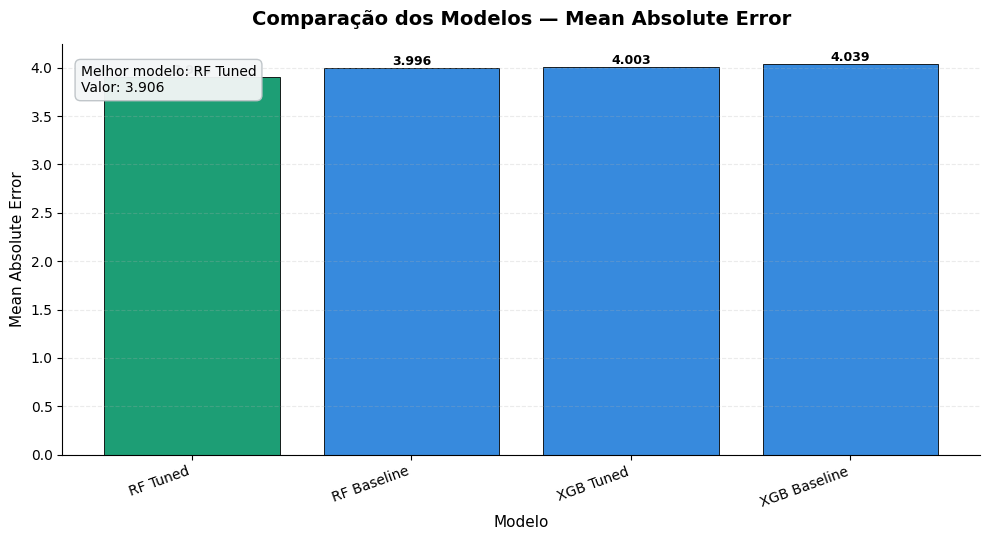

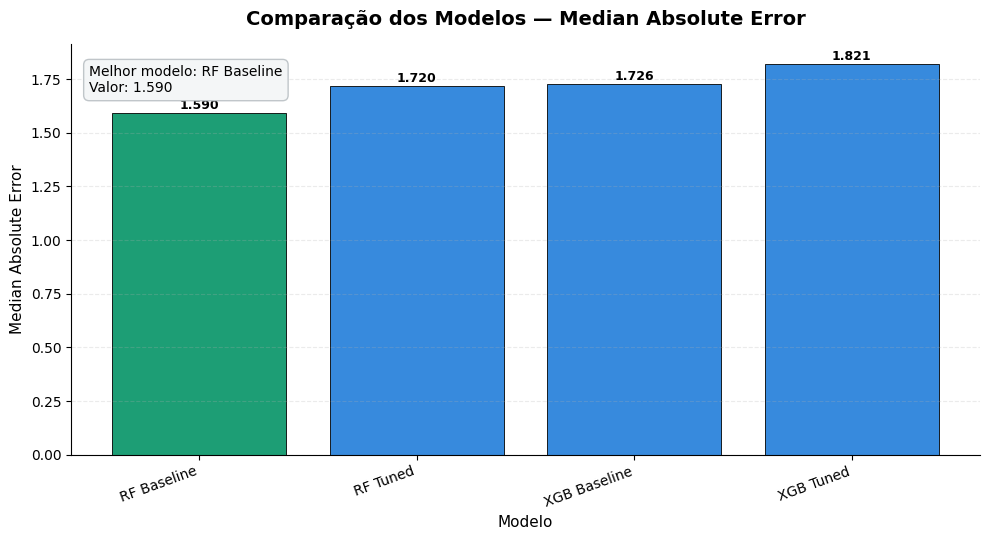

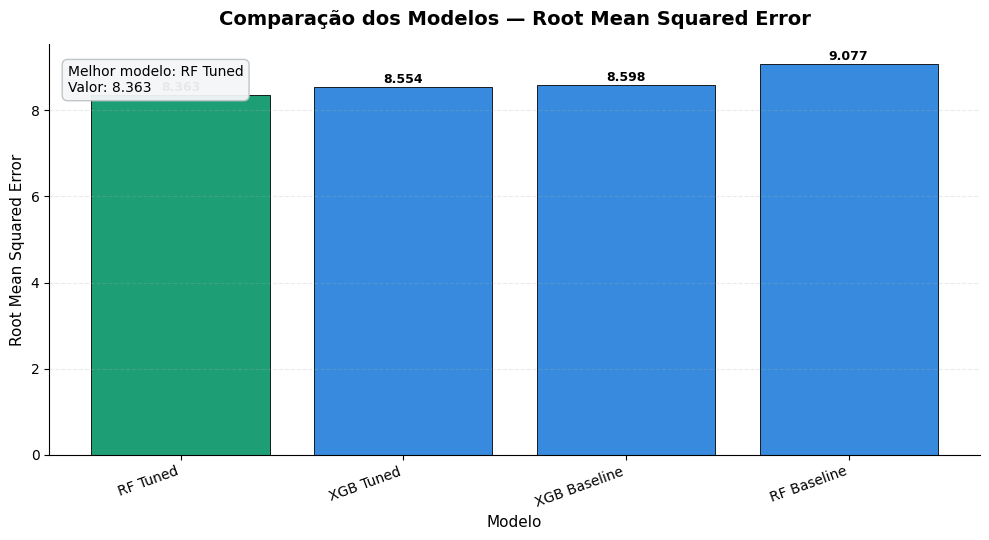

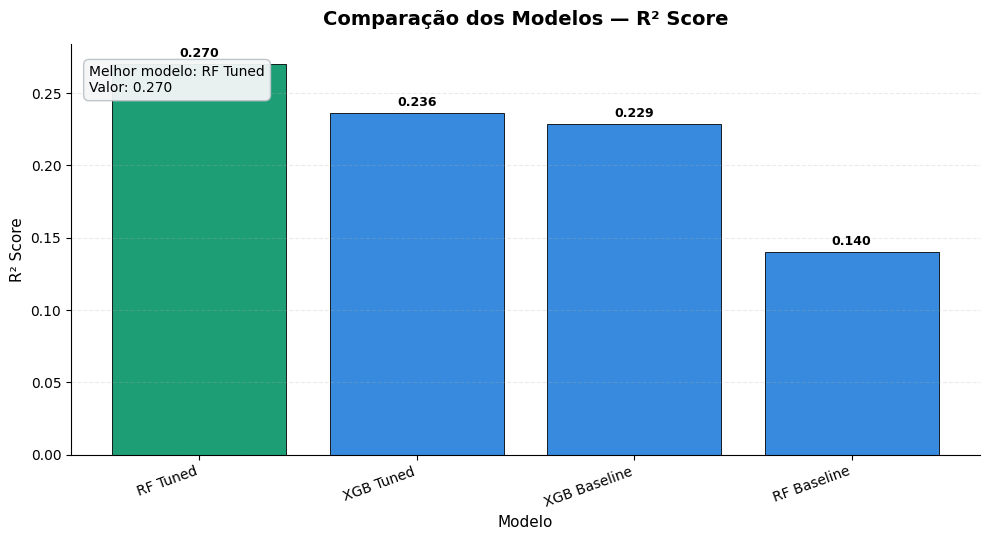

In [62]:
# ============================================================
# 6.2 — METRIC COMPARISON PLOTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ["MAE", "MedianAE", "RMSE", "R2"]

metric_labels = {
    "MAE": "Mean Absolute Error",
    "MedianAE": "Median Absolute Error",
    "RMSE": "Root Mean Squared Error",
    "R2": "R² Score"
}

best_color = "#1D9E75"
normal_color = "#378ADD"
bad_color = "#C0392B"

for metric in metrics_to_plot:
    ascending = metric != "R2"
    ordered = results_df.sort_values(metric, ascending=ascending).reset_index(drop=True)

    colors = [
        best_color if i == 0 else normal_color
        for i in range(len(ordered))
    ]

    plt.figure(figsize=(10, 5.5))

    bars = plt.bar(
        ordered["Model"],
        ordered[metric],
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    for bar, value in zip(bars, ordered[metric]):
        y_offset = 0.02 * (ordered[metric].max() - ordered[metric].min() + 1e-9)

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_offset,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    best_model_for_metric = ordered.iloc[0]["Model"]
    best_value = ordered.iloc[0][metric]

    plt.title(
        f"Comparação dos Modelos — {metric_labels[metric]}",
        fontsize=14,
        fontweight="bold",
        pad=14
    )

    plt.ylabel(metric_labels[metric], fontsize=11)
    plt.xlabel("Modelo", fontsize=11)

    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.25)

    plt.text(
        0.02,
        0.95,
        f"Melhor modelo: {best_model_for_metric}\nValor: {best_value:.3f}",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#F4F6F7",
            edgecolor="#BDC3C7",
            alpha=0.95
        )
    )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

## 6.3 Análise dos Erros de Previsão

Para além das métricas agregadas, é importante analisar a distribuição dos erros.

Nesta secção são avaliados:

- erro absoluto médio;
- erro mediano;
- percentis dos erros;
- erro máximo;
- tendência para subestimar ou sobrestimar o tempo de internamento.

In [50]:
# ============================================================
# 6.3 — ERROR DISTRIBUTION TABLE
# ============================================================

print(f"Error analysis performed on: {best_model_name}")

error = y_test - best_pred
abs_error = np.abs(error)

error_stats = pd.DataFrame({
    "Model": [best_model_name] * 9,
    "Statistic": [
        "Mean Error",
        "Median Error",
        "Mean Absolute Error",
        "Median Absolute Error",
        "25th Percentile Absolute Error",
        "75th Percentile Absolute Error",
        "90th Percentile Absolute Error",
        "95th Percentile Absolute Error",
        "Maximum Absolute Error"
    ],
    "Value": [
        np.mean(error),
        np.median(error),
        np.mean(abs_error),
        np.median(abs_error),
        np.percentile(abs_error, 25),
        np.percentile(abs_error, 75),
        np.percentile(abs_error, 90),
        np.percentile(abs_error, 95),
        np.max(abs_error)
    ]
})

error_stats

Error analysis performed on: RF Tuned


,Model,Statistic,Value
0,RF Tuned,Mean Error,-0.051575
1,RF Tuned,Median Error,-1.201739
2,RF Tuned,Mean Absolute Error,3.905558
3,RF Tuned,Median Absolute Error,1.720006
4,RF Tuned,25th Percentile Absolute Error,0.971366
5,RF Tuned,75th Percentile Absolute Error,3.608956
6,RF Tuned,90th Percentile Absolute Error,8.801242
7,RF Tuned,95th Percentile Absolute Error,14.154217
8,RF Tuned,Maximum Absolute Error,136.505788


### Interpretação dos Erros

O melhor modelo (RF Tuned) apresentou um erro absoluto médio (MAE) de aproximadamente **3.91 dias**, enquanto o erro absoluto mediano foi de apenas **1.72 dias**.

A diferença significativa entre o MAE e o erro absoluto mediano sugere a existência de alguns casos extremos com erros elevados, que aumentam a média global do erro. Esta interpretação é confirmada pelo erro absoluto máximo observado, superior a **136 dias**, indicando dificuldades na previsão de internamentos muito longos.

O facto de 50% das previsões apresentarem um erro inferior a cerca de **1.7 dias** demonstra que o modelo obtém um desempenho razoável para a maioria dos doentes.

Adicionalmente, o erro médio foi de aproximadamente **−0.05 dias**, um valor muito próximo de zero, sugerindo que o modelo não apresenta uma tendência sistemática relevante para sobrestimar ou subestimar o tempo de internamento.

Em conjunto, estes resultados indicam que o modelo produz previsões relativamente precisas para a maioria dos casos, mas continua a enfrentar dificuldades na modelação de internamentos excecionalmente longos, que representam os principais responsáveis pelos erros mais elevados observados.

## 6.4 Valores Reais vs Valores Previstos

Este gráfico compara os valores reais de LOS com os valores previstos pelo melhor modelo.

A linha diagonal representa previsões perfeitas. Quanto mais próximos os pontos estiverem desta linha, melhor é a capacidade preditiva do modelo.

Desvios significativos da diagonal indicam casos em que o modelo subestimou ou sobrestimou o tempo de internamento.

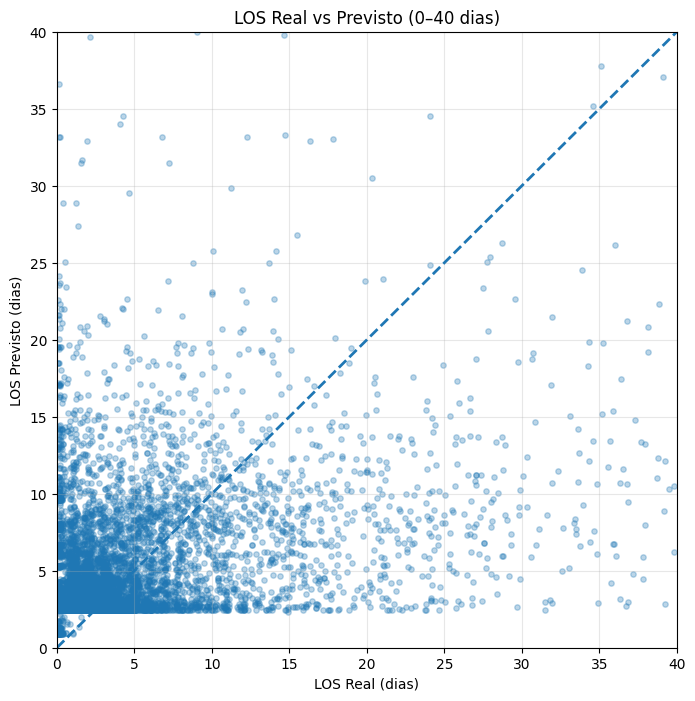

In [51]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.3,
    s=15
)

plt.plot(
    [0,40],
    [0,40],
    "--",
    linewidth=2
)

plt.xlim(0,40)
plt.ylim(0,40)

plt.xlabel("LOS Real (dias)")
plt.ylabel("LOS Previsto (dias)")
plt.title("LOS Real vs Previsto (0–40 dias)")

plt.grid(alpha=0.3)
plt.show()

### Interpretação do Gráfico Real vs Previsto

Observa-se uma concentração das previsões em torno da região central da distribuição do LOS, indicando que o modelo apresenta dificuldade em capturar internamentos extremamente curtos ou extremamente prolongados.

Este comportamento é consistente com a elevada assimetria da variável alvo, em que a maioria dos doentes apresenta estadias relativamente curtas, enquanto um número reduzido de casos apresenta internamentos muito longos.

Assim, o modelo demonstra melhor desempenho para a região mais frequente da distribuição, mas tende a subestimar casos extremos de longa duração.

## 6.5 Análise dos Resíduos

A análise dos resíduos permite verificar se o modelo apresenta tendência sistemática para sobrestimar ou subestimar o LOS.

Idealmente, os resíduos devem estar distribuídos em torno de zero, sem padrões evidentes. A presença de assimetrias ou dispersão crescente pode indicar dificuldades do modelo em prever estadias muito longas.

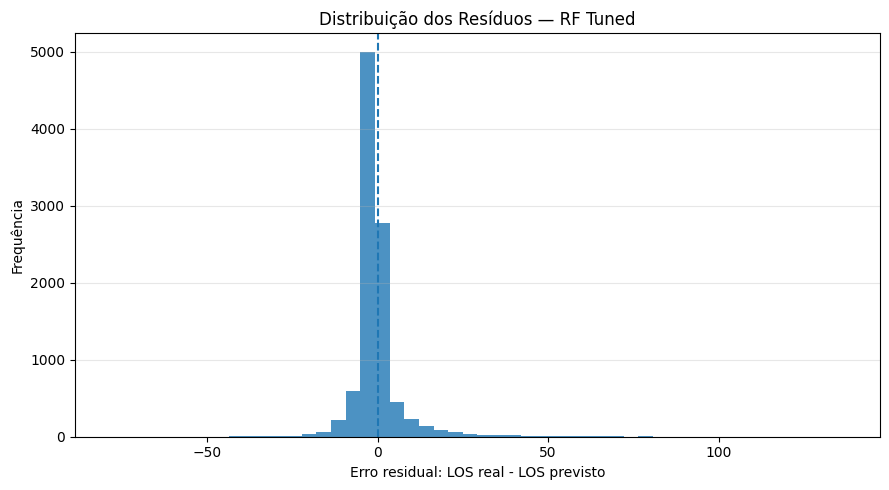

In [52]:
# ============================================================
# 6.5 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(error, bins=50, alpha=0.8)
plt.axvline(0, linestyle="--")

plt.xlabel("Erro residual: LOS real - LOS previsto")
plt.ylabel("Frequência")
plt.title(f"Distribuição dos Resíduos — {best_model_name}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

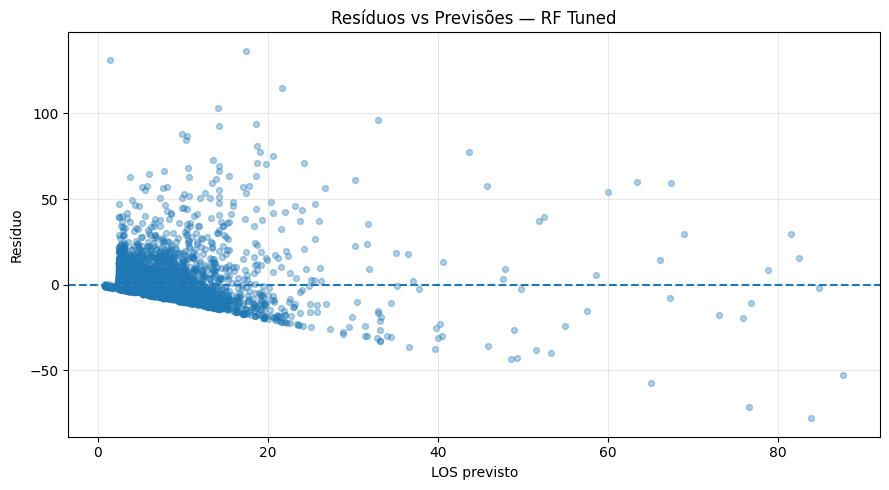

In [53]:
# ============================================================
# 6.5 — RESIDUALS VS PREDICTED
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(best_pred, error, alpha=0.35, s=18)
plt.axhline(0, linestyle="--")

plt.xlabel("LOS previsto")
plt.ylabel("Resíduo")
plt.title(f"Resíduos vs Previsões — {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6.6 Erro por Duração de Internamento

Esta tabela e o gráfico mostram como o erro varia em função da duração real do internamento.

Esta análise é particularmente relevante porque estadias longas são menos frequentes, mas mais difíceis de prever. Um aumento do erro nos grupos de LOS mais elevado pode indicar que o modelo tem maior dificuldade em capturar casos clínicos extremos.

In [54]:
# ============================================================
# 6.6 — ERROR BY LOS RANGE
# ============================================================

error_by_range = pd.DataFrame({
    "y_true": y_test,
    "y_pred": best_pred,
    "abs_error": abs_error
})

error_by_range["LOS Group"] = pd.cut(
    error_by_range["y_true"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=["0-2 days", "2-5 days", "5-10 days", "10-20 days", "20+ days"]
)

los_group_stats = (
    error_by_range
    .groupby("LOS Group", observed=True)
    .agg(
        Count=("abs_error", "count"),
        MAE=("abs_error", "mean"),
        MedianAE=("abs_error", "median"),
        RMSE=("abs_error", lambda x: np.sqrt(np.mean(x ** 2)))
    )
    .reset_index()
)

los_group_stats

,LOS Group,Count,MAE,MedianAE,RMSE
0,0-2 days,4843,2.710968,1.684004,4.137474
1,2-5 days,2811,1.625125,0.805641,2.965841
2,5-10 days,1108,3.605517,2.823621,5.972839
3,10-20 days,631,7.199854,7.140381,8.501015
4,20+ days,461,26.572462,20.488422,32.817203


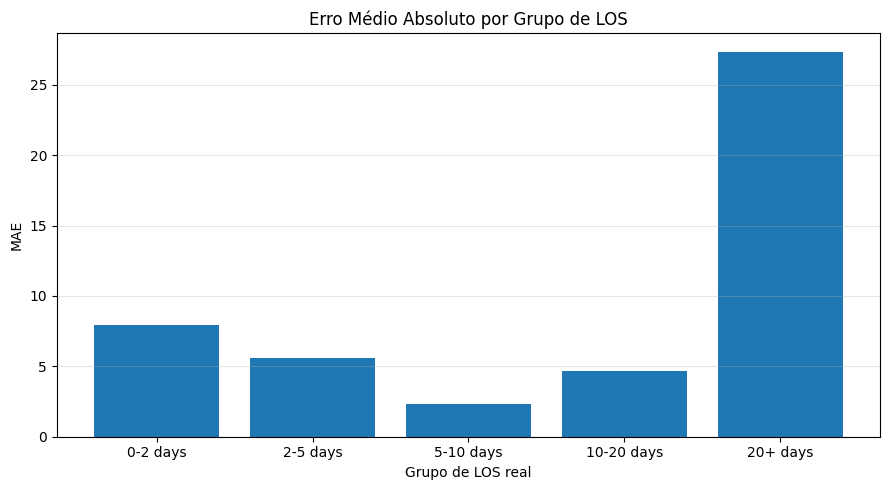

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(los_group_stats["LOS Group"].astype(str), los_group_stats["MAE"])

plt.xlabel("Grupo de LOS real")
plt.ylabel("MAE")
plt.title("Erro Médio Absoluto por Grupo de LOS")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Erro por Duração de Internamento

Esta análise avalia como o erro de previsão varia em função da duração real do internamento.

A divisão por grupos de LOS permite identificar se o modelo apresenta desempenho diferente em estadias curtas, médias ou prolongadas.

Esta análise é particularmente relevante porque os internamentos longos são menos frequentes, mas têm maior impacto clínico e operacional.

Um aumento do erro nos grupos de LOS mais elevado indica dificuldade do modelo em capturar casos extremos, fenómeno comum em problemas com distribuições assimétricas.

## 6.7 Importância das Variáveis

A análise de importância das variáveis permite identificar quais os sinais clínicos mais relevantes para a previsão do tempo de internamento.

Variáveis com maior importância contribuem mais frequentemente para reduzir o erro durante a construção das árvores do modelo.

Esta análise é particularmente útil em contexto clínico, pois permite relacionar o desempenho preditivo com indicadores fisiológicos observáveis nas primeiras horas de internamento.

In [55]:
# ============================================================
# 6.7 — FEATURE IMPORTANCE
# ============================================================

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    top20_importance = importance_df.head(20)
    display(top20_importance)

else:
    print("O modelo seleccionado não possui atributo feature_importances_.")

,Feature,Importance
0,211,0.561523
43,113,0.218556
39,723,0.072400
36,220050,0.018787
26,51,0.011008
3,646,0.010993
5,220210,0.010971
2,618,0.009816
13,581,0.008275
4,220045,0.006326


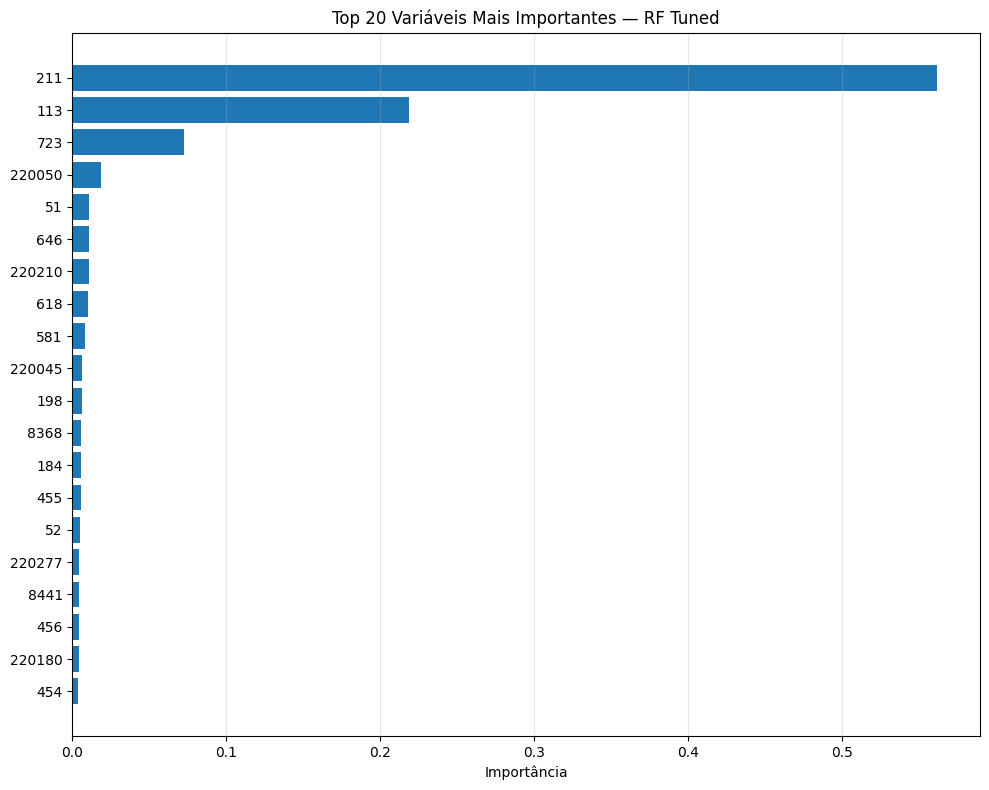

In [56]:
# ============================================================
# 6.7 — FEATURE IMPORTANCE PLOT
# ============================================================

if hasattr(best_model, "feature_importances_"):
    plt.figure(figsize=(10, 8))

    plt.barh(
        top20_importance["Feature"][::-1],
        top20_importance["Importance"][::-1]
    )

    plt.xlabel("Importância")
    plt.title(f"Top 20 Variáveis Mais Importantes — {best_model_name}")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Interpretação da Importância das Variáveis

A análise da importância das variáveis revela que o modelo Random Forest atribuiu um peso muito superior ao **ITEMID 211**, responsável por aproximadamente **56% da importância total** do modelo. Este resultado sugere que esta variável contém uma quantidade substancial de informação relevante para a previsão do tempo de internamento.

A segunda variável mais importante foi o **ITEMID 113**, com cerca de **22% da importância total**, enquanto os restantes atributos apresentam contribuições significativamente inferiores. Em conjunto, os dois atributos mais relevantes representam mais de **75% da importância acumulada**, indicando que uma parte considerável da capacidade preditiva do modelo está concentrada num número reduzido de variáveis.

Observa-se ainda uma queda acentuada de importância após os primeiros atributos, sendo que a maioria das restantes variáveis apresenta valores inferiores a 2%. Este comportamento sugere que muitos dos sinais clínicos incluídos no modelo possuem um contributo marginal para a previsão da duração do internamento.

No entanto, a interpretação clínica destes resultados é limitada pelo facto de as variáveis serem apresentadas apenas através dos seus **ITEMIDs**. Para uma análise mais aprofundada, seria recomendável relacionar estes identificadores com as respetivas descrições clínicas presentes na tabela **D_ITEMS**, permitindo compreender quais os sinais vitais, medições laboratoriais ou observações clínicas que exercem maior influência nas previsões do modelo.

Apesar desta limitação, os resultados demonstram que o modelo conseguiu identificar um pequeno conjunto de atributos altamente informativos, utilizando-os como principal base para estimar o tempo de permanência hospitalar dos doentes.

In [57]:
# ============================================================
# 6.8 — SAVE RESULTS
# ============================================================

results_df.to_csv("model_comparison_results.csv", index=False)
error_stats.to_csv("prediction_error_statistics.csv", index=False)

if "importance_df" in globals():
    importance_df.to_csv("feature_importance.csv", index=False)

print("Results saved:")
print("- model_comparison_results.csv")
print("- prediction_error_statistics.csv")
print("- feature_importance.csv")

Results saved:
- model_comparison_results.csv
- prediction_error_statistics.csv
- feature_importance.csv


## 6.8 Discussão dos Resultados

A comparação dos modelos demonstrou que o **Random Forest Tuned** apresentou o melhor desempenho global, obtendo o menor erro de previsão entre os modelos avaliados e sendo, por isso, selecionado como modelo final para análise detalhada.

Os resultados mostram que o problema da previsão da duração de internamento (Length of Stay – LOS) continua a ser um desafio complexo. Embora o modelo tenha conseguido alcançar erros médios relativamente reduzidos para uma parte significativa dos doentes, a presença de internamentos muito prolongados originou alguns erros extremos, refletidos na diferença observada entre o erro absoluto mediano e o erro absoluto máximo.

A análise da distribuição dos erros revelou que metade das previsões apresenta um erro inferior a aproximadamente dois dias, indicando um desempenho satisfatório para a maioria dos casos. Por outro lado, os internamentos excecionalmente longos continuam a ser mais difíceis de prever, contribuindo de forma desproporcional para o aumento das métricas de erro globais.

A avaliação por grupos de duração de internamento confirmou esta tendência. Os erros tendem a aumentar à medida que a duração real do internamento cresce, fenómeno expectável devido à menor frequência destes casos no conjunto de dados e à maior variabilidade clínica associada a internamentos prolongados.

Relativamente à importância das variáveis, observou-se que um número reduzido de atributos concentra grande parte da capacidade preditiva do modelo. Em particular, os atributos correspondentes aos ITEMIDs mais relevantes contribuíram de forma dominante para as previsões realizadas pelo Random Forest. Este resultado sugere que determinadas medições clínicas recolhidas durante as primeiras 48 horas de internamento possuem um valor preditivo significativamente superior ao das restantes variáveis consideradas.

Em termos gerais, os resultados demonstram que técnicas de Machine Learning conseguem extrair informação útil dos dados clínicos iniciais e produzir estimativas razoáveis da duração de internamento. No entanto, o desempenho obtido também evidencia as limitações inerentes à previsão de eventos clínicos complexos, especialmente nos casos mais raros e prolongados, onde fatores não observados no conjunto de dados podem desempenhar um papel determinante.


---
# Capítulo 7 — Performance e Profiling

Neste capítulo é analisado o desempenho computacional do pipeline desenvolvido.

Como o ficheiro `CHARTEVENTS.csv.gz` possui dimensão elevada, a eficiência das operações de leitura, transformação, agregação e treino dos modelos é um aspecto essencial do projecto.

São analisados:

- tempo das fases principais do pipeline;
- tempo de treino e optimização dos modelos;
- impacto do uso de PySpark;
- impacto do formato Parquet;
- paralelismo local com `local[*]`;
- paralelismo dos modelos com `n_jobs=-1`;
- profiling das fases críticas com `cProfile`.

In [58]:

import pandas as pd

performance_summary = pd.DataFrame({
    "Stage": [
        "CSV to Parquet conversion",
        "48h window filtering",
        "Pivot / feature engineering",
        "Median imputation",
        "Random Forest GridSearchCV",
        "XGBoost RandomizedSearchCV"
    ],
    "Tool / Library": [
        "PySpark",
        "PySpark",
        "PySpark",
        "PySpark",
        "scikit-learn",
        "scikit-learn + XGBoost"
    ],
    "Parallelism": [
        "local[*]",
        "local[*]",
        "local[*]",
        "local[*]",
        "n_jobs=-1",
        "n_jobs=-1"
    ],
    "Notes": [
        "One-time conversion from compressed CSV to Parquet",
        "Filters events to first 48h after admission",
        "Transforms long event table into wide ML table",
        "Computes median per feature and fills nulls",
        "Exhaustive search over RF hyperparameters",
        "Randomized search over XGBoost hyperparameters"
    ]
})

performance_summary

,Stage,Tool / Library,Parallelism,Notes
0,CSV to Parquet conversion,PySpark,local[*],One-time conversion from compressed CSV to Par...
1,48h window filtering,PySpark,local[*],Filters events to first 48h after admission
2,Pivot / feature engineering,PySpark,local[*],Transforms long event table into wide ML table
3,Median imputation,PySpark,local[*],Computes median per feature and fills nulls
4,Random Forest GridSearchCV,scikit-learn,n_jobs=-1,Exhaustive search over RF hyperparameters
5,XGBoost RandomizedSearchCV,scikit-learn + XGBoost,n_jobs=-1,Randomized search over XGBoost hyperparameters


## 7.2 Tempos de Execução

Esta tabela resume as principais fases computacionais do projecto.

As operações sobre o ficheiro `CHARTEVENTS` foram realizadas em PySpark, uma vez que o volume de dados original inviabiliza o processamento eficiente com Pandas puro.

A conversão para Parquet representa uma etapa particularmente importante, pois reduz significativamente o tempo de leitura nas execuções seguintes.

In [59]:
# ============================================================
# 7.2 — TEMPOS DE EXECUÇÃO DAS FASES DO PIPELINE
# ============================================================

timing_rows = []

if "rf_time" in globals():
    timing_rows.append({"Fase": "Random Forest baseline", "Tempo (s)": round(rf_time, 1),
                         "Ferramenta": "scikit-learn", "Paralelismo": "n_jobs=-1"})

if "xgb_time" in globals():
    timing_rows.append({"Fase": "XGBoost baseline", "Tempo (s)": round(xgb_time, 1),
                         "Ferramenta": "XGBoost", "Paralelismo": "n_jobs=-1"})

if "rf_search_time" in globals():
    timing_rows.append({"Fase": "Random Forest GridSearchCV (5-fold)",
                         "Tempo (s)": round(rf_search_time, 1),
                         "Ferramenta": "scikit-learn", "Paralelismo": "n_jobs=-1"})
else:
    timing_rows.append({"Fase": "Random Forest GridSearchCV (5-fold)",
                         "Tempo (s)": "N/D — re-executar célula 5.4",
                         "Ferramenta": "scikit-learn", "Paralelismo": "n_jobs=-1"})

if "xgb_search_time" in globals():
    timing_rows.append({"Fase": "XGBoost RandomizedSearchCV (5-fold, 20 iter)",
                         "Tempo (s)": round(xgb_search_time, 1),
                         "Ferramenta": "scikit-learn + XGBoost", "Paralelismo": "n_jobs=-1"})
else:
    timing_rows.append({"Fase": "XGBoost RandomizedSearchCV (5-fold, 20 iter)",
                         "Tempo (s)": "N/D — re-executar célula 5.6",
                         "Ferramenta": "scikit-learn + XGBoost", "Paralelismo": "n_jobs=-1"})

timing_df = pd.DataFrame(timing_rows)
timing_df


,Fase,Tempo (s),Ferramenta,Paralelismo
0,Random Forest baseline,8.3,scikit-learn,n_jobs=-1
1,XGBoost baseline,0.7,XGBoost,n_jobs=-1
2,Random Forest GridSearchCV (5-fold),957.8,scikit-learn,n_jobs=-1
3,"XGBoost RandomizedSearchCV (5-fold, 20 iter)",34.8,scikit-learn + XGBoost,n_jobs=-1


## 7.3 Profiling das Previsões

Para além da medição dos tempos globais de execução, foi realizado *profiling* das operações de inferência do modelo final utilizando a biblioteca `cProfile`.

O objectivo consiste em identificar as funções que consomem mais tempo durante a geração de previsões, permitindo compreender quais os componentes computacionais mais exigentes do pipeline.

Esta análise fornece uma visão mais detalhada do comportamento interno do modelo, complementando as métricas globais de desempenho apresentadas anteriormente.

In [60]:
# ============================================================
# 7.3 — PROFILING BEST MODEL PREDICTION
# ============================================================

import cProfile
import pstats
import io

def profile_prediction():
    _ = best_model.predict(X_test)

profiler = cProfile.Profile()
profiler.enable()

profile_prediction()

profiler.disable()

s = io.StringIO()
stats = pstats.Stats(profiler, stream=s).sort_stats("cumtime")
stats.print_stats(20)

print(s.getvalue())

         49233 function calls (47247 primitive calls) in 0.056 seconds

   Ordered by: cumulative time
   List reduced from 414 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.093    0.046 C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\multiprocessing\connection.py:131(__del__)
        2    0.000    0.000    0.093    0.046 C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\multiprocessing\connection.py:277(_close)
        2    0.000    0.000    0.092    0.046 {built-in method _winapi.CloseHandle}
        6    0.000    0.000    0.089    0.015 C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\multiprocessing\queues.py:374(empty)
        6    0.000    0.000    0.089    0.015 C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.

## 7.4 Resultados do Profiling

Os resultados do profiling permitem identificar as funções com maior tempo acumulado de execução (*cumulative time*).

A análise concentra-se nas chamadas mais dispendiosas, uma vez que estas representam os principais pontos de custo computacional durante a fase de inferência.

A informação obtida é útil para compreender a eficiência do modelo seleccionado e para identificar possíveis oportunidades de optimização em futuras versões do pipeline.

In [61]:
# ============================================================
# 7.4 — SAVE PROFILING OUTPUT
# ============================================================

with open("profiling_best_model_prediction.txt", "w") as f:
    f.write(s.getvalue())

print("Profiling saved to profiling_best_model_prediction.txt")

Profiling saved to profiling_best_model_prediction.txt


## 7.5 Discussão sobre Paralelismo e Eficiência

O pipeline utiliza paralelismo em duas fases principais.

Primeiro, as operações de ingestão, filtragem temporal e agregação são realizadas com PySpark. A sessão Spark foi executada em modo local utilizando `local[*]`, permitindo o uso dos núcleos disponíveis da máquina para paralelizar tarefas de leitura e transformação.

Segundo, os modelos de Machine Learning foram treinados com paralelismo ao nível da biblioteca scikit-learn e XGBoost, utilizando `n_jobs=-1`. Esta configuração permite distribuir o treino das árvores e das combinações de hiperparâmetros pelos núcleos disponíveis.

A utilização de Parquet foi essencial para melhorar a eficiência do pipeline. Ao contrário do CSV comprimido, o Parquet é colunar, comprimido e optimizado para leitura selectiva de colunas. Isto reduz o custo das operações repetidas durante a análise exploratória e feature engineering.

## 7.6 Limitações Computacionais

Apesar das optimizações aplicadas, existem limitações associadas à execução local.

O processamento foi realizado numa única máquina, o que limita a capacidade de paralelismo quando comparado com um cluster Spark distribuído.

A conversão inicial do `CHARTEVENTS.csv.gz` para Parquet foi a fase mais exigente em termos de disco e memória, uma vez que envolve leitura, descompressão, ordenação e escrita de um volume elevado de dados.

A pesquisa de hiperparâmetros também apresentou custo computacional elevado, especialmente no caso do Random Forest, onde o `GridSearchCV` treinou múltiplas combinações de parâmetros com validação cruzada.

Como melhoria futura, o pipeline poderia ser executado num ambiente distribuído, como Databricks, Google Cloud Dataproc ou BigQuery, reduzindo significativamente o tempo de processamento das fases mais pesadas.

*(Célula de rascunho removida — código de imputação consolidado na secção 4.2.)*
